In [3]:
import pandas as pd

# Path pattern: /kaggle/input/<dataset-name>/<your-file-name.parquet>
# If dataset folder name matches 'My_DATA':
file_path = '/kaggle/input/datasets/syednaseer111/my-data/merged_combat_corrected.parquet'  # Kaggle converts dataset titles to lowercase slugs

# Load and inspect
df = pd.read_parquet(file_path)
df.head()

,Sample_ID,Cohort,Condition,A1CF,A2M,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZSCAN5A,ZSWIM1,ZW10,ZWILCH,ZWINT,ZXDA,ZXDC,ZYX,ZZEF1,ZZZ3
0,GSM254625,GSE10072,A,-4.573068,11.274854,1.699760,-2.346975,3.388262,4.817479,2.218527,...,3.101897,2.728153,6.238978,4.659017,7.583475,4.622320,5.876146,10.169101,2.169935,9.116263
1,GSM254626,GSE10072,N,-0.930926,14.400561,3.095633,1.436989,3.671334,6.347273,2.979446,...,4.573486,4.018124,7.072999,4.479785,3.797851,3.433141,8.570018,10.310640,2.124172,7.516199
2,GSM254627,GSE10072,A,6.005920,1.772589,7.512613,3.386970,6.410457,15.793604,3.380698,...,5.395371,9.295366,10.715370,8.601205,12.669836,7.247294,4.202262,6.620161,6.562734,6.834262
3,GSM254628,GSE10072,N,2.101315,13.324066,2.614170,1.572582,4.259665,4.490010,5.343849,...,4.888815,2.791093,6.068779,4.449116,4.033401,4.309501,10.289107,8.703607,4.527412,7.475831
4,GSM254629,GSE10072,A,6.042764,7.057474,2.876202,1.134853,7.345965,2.986229,2.040224,...,3.058481,5.909356,9.347651,5.194133,4.861309,5.873630,7.097598,7.135665,4.847837,7.066575


In [6]:
# Cohort-wise class distribution
cohort_class_counts = pd.crosstab(
    df['Cohort'], 
    df['Condition'], 
    margins=True, 
    margins_name='Total'
)

print("=== Cohort-wise Class Sample Distribution ===")
print(cohort_class_counts)

=== Cohort-wise Class Sample Distribution ===
Condition     A    N    S  Total
Cohort                          
GSE10072     58   49    0    107
GSE27262     25   25    0     50
GSE30219      0   14  293    307
GSE31210    246    0    0    246
GSE33479      0   27   95    122
GSE68465    443   19    0    462
ICGC        488   55    0    543
TCGA        541  110  502   1153
Total      1801  299  890   2990


# LungXAI_Pipe Line

In [3]:
import os
import sys
import random
import warnings
import json
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# Helper Context Manager to Silence C++ Stream Logs (Stderr Redirect)
# -------------------------------------------------------------------
class SuppressStderr:
    def __enter__(self):
        sys.stderr.flush()
        self._err_null = open(os.devnull, 'w')
        self._old_stderr_fd = os.dup(2)
        os.dup2(self._err_null.fileno(), 2)

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stderr.flush()
        os.dup2(self._old_stderr_fd, 2)
        os.close(self._old_stderr_fd)
        self._err_null.close()

# Suppress C++ TensorFlow warnings & Python level warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------
# 0. Set Seeds & Determinism for 100% Reproducibility
# -------------------------------------------------------------------
SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
tf.get_logger().setLevel('FATAL')

try:
    tf.config.experimental.enable_op_determinism()
except AttributeError:
    pass

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, accuracy_score

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from IPython.display import FileLink, display

import lime
import lime.lime_tabular

# -------------------------------------------------------------------
# 1. GPU Setup
# -------------------------------------------------------------------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Running on GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ Running on CPU.")

# -------------------------------------------------------------------
# 2. Data Preparation
# -------------------------------------------------------------------
file_path = '/kaggle/input/datasets/syednaseer111/my-data/merged_combat_corrected.parquet'
df = pd.read_parquet(file_path)

label_encoder = LabelEncoder()
df['Condition_Encoded'] = label_encoder.fit_transform(df['Condition'])

metadata_cols = ['Sample_ID', 'Cohort', 'Condition', 'Condition_Encoded']
gene_cols = [col for col in df.columns if col not in metadata_cols]

X_all = df[gene_cols].values
y_all = df['Condition_Encoded'].values

num_genes = len(gene_cols)
num_classes = len(label_encoder.classes_)
class_names = [str(c) for c in label_encoder.classes_]

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

# -------------------------------------------------------------------
# 3. Learning Rate Warmup Callback
# -------------------------------------------------------------------
class WarmupScheduler(tf.keras.callbacks.Callback):
    def __init__(self, warmup_epochs=3, target_lr=1.5e-4, initial_lr=1e-5):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.target_lr = target_lr
        self.initial_lr = initial_lr

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.initial_lr + (self.target_lr - self.initial_lr) * ((epoch + 1) / self.warmup_epochs)
            if hasattr(self.model.optimizer, 'learning_rate'):
                self.model.optimizer.learning_rate.assign(lr)
            else:
                tf.keras.backend.set_value(self.model.optimizer.lr, lr)

# -------------------------------------------------------------------
# 4. 1D-CNN Architecture
# -------------------------------------------------------------------
def build_direct_1d_cnn(input_shape, num_classes, seed=42):
    l2_penalty = 1.5e-4
    initializer = tf.keras.initializers.GlorotUniform(seed=seed)
    
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        layers.Conv1D(filters=32, kernel_size=5, strides=2, activation='relu', 
                      kernel_initializer=initializer,
                      kernel_regularizer=regularizers.l2(l2_penalty)),
        layers.SpatialDropout1D(0.08, seed=seed),
        layers.MaxPooling1D(pool_size=2),
        layers.BatchNormalization(),
        
        layers.Conv1D(filters=64, kernel_size=3, strides=2, activation='relu', 
                      kernel_initializer=initializer,
                      kernel_regularizer=regularizers.l2(l2_penalty)),
        layers.SpatialDropout1D(0.08, seed=seed),
        layers.MaxPooling1D(pool_size=2),
        layers.BatchNormalization(),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_initializer=initializer, kernel_regularizer=regularizers.l2(l2_penalty)),
        layers.Dropout(0.30, seed=seed),
        layers.Dense(64, activation='relu', kernel_initializer=initializer, kernel_regularizer=regularizers.l2(l2_penalty)),
        layers.Dropout(0.30, seed=seed),
        layers.Dense(num_classes, activation='softmax', kernel_initializer=initializer)
    ])
    return model

# -------------------------------------------------------------------
# 5. 10-Fold CV Loop Execution
# -------------------------------------------------------------------
all_y_true = []
all_y_pred_probs = []
all_histories = []
fold_auc_scores = []
fold_acc_scores = []
all_fold_gene_importances = []

print(f"\n--- Starting 10-Fold Cross-Validation on Direct Genes ({num_genes} features) ---")

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all)):
    print(f"--- Running Fold {fold + 1}/10 ---")

    X_train, y_train = X_all[train_idx], y_all[train_idx]
    X_test, y_test = X_all[test_idx], y_all[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    smote = SMOTE(random_state=SEED)
    X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

    X_train_cnn = np.expand_dims(X_train_res, axis=-1)
    X_test_cnn = np.expand_dims(X_test_scaled, axis=-1)

    warmup = WarmupScheduler(warmup_epochs=3, target_lr=1.5e-4, initial_lr=1e-5)
    early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6, verbose=0)

    # Wrap model training and evaluation in SuppressStderr to catch lower C++ engine logs
    with SuppressStderr():
        with tf.device('/GPU:0' if gpus else '/CPU:0'):
            model = build_direct_1d_cnn(input_shape=(num_genes, 1), num_classes=num_classes, seed=SEED + fold)
            
            optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5, clipnorm=0.8)
            model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

            history = model.fit(
                X_train_cnn, y_train_res,
                epochs=40,
                batch_size=64,
                validation_data=(X_test_cnn, y_test),
                callbacks=[warmup, early_stop, lr_scheduler],
                verbose=0
            )
            all_histories.append(history.history)

            y_preds_proba = model.predict(X_test_cnn, verbose=0)

        all_y_true.extend(y_test)
        all_y_pred_probs.append(y_preds_proba)

        y_preds_class = np.argmax(y_preds_proba, axis=1)
        fold_auc = roc_auc_score(y_test, y_preds_proba, multi_class='ovr', labels=np.arange(num_classes))
        fold_acc = accuracy_score(y_test, y_preds_class)

        fold_auc_scores.append(fold_auc)
        fold_acc_scores.append(fold_acc)

        def predict_fn(gene_2d_array):
            cnn_input = np.expand_dims(gene_2d_array, axis=-1)
            with tf.device('/GPU:0' if gpus else '/CPU:0'):
                preds = model.predict(cnn_input, verbose=0)
            return preds

        explainer = lime.lime_tabular.LimeTabularExplainer(
            training_data=X_train_res,
            feature_names=gene_cols,
            class_names=class_names,
            mode='classification',
            random_state=SEED
        )

        exp = explainer.explain_instance(
            data_row=X_test_scaled[0],
            predict_fn=predict_fn,
            num_features=100
        )

        direct_gene_weights = np.zeros(num_genes)
        target_class_idx = list(exp.local_exp.keys())[0]

        for feature_idx, weight in exp.local_exp[target_class_idx]:
            direct_gene_weights[feature_idx] = weight

        all_fold_gene_importances.append(direct_gene_weights)

    # Print results cleanly after the fold completes
    print(f"Fold {fold + 1} Results -> Accuracy: {fold_acc:.4f} | AUC: {fold_auc:.4f}")

# -------------------------------------------------------------------
# 6. Save Raw Results to File
# -------------------------------------------------------------------
all_y_true = np.array(all_y_true)
all_y_pred_probs = np.vstack(all_y_pred_probs)
all_y_pred_classes = np.argmax(all_y_pred_probs, axis=1)

histories_json = json.dumps(all_histories)
np.savez_compressed(
    'model_10fold_results_and_history_no_pca.npz',
    y_true=all_y_true,
    y_pred_probs=all_y_pred_probs,
    y_pred_classes=all_y_pred_classes,
    fold_auc_scores=np.array(fold_auc_scores),
    fold_acc_scores=np.array(fold_acc_scores),
    gene_importances=np.array(all_fold_gene_importances),
    gene_names=np.array(gene_cols),
    class_names=np.array(class_names),
    histories_json=histories_json
)

print("\n✅ Training Complete. All raw fold results exported to 'model_10fold_results_and_history_no_pca.npz'.")
display(FileLink('model_10fold_results_and_history_no_pca.npz'))

✅ Running on GPU: /physical_device:GPU:0

--- Starting 10-Fold Cross-Validation on Direct Genes (11494 features) ---
--- Running Fold 1/10 ---
Fold 1 Results -> Accuracy: 0.9699 | AUC: 0.9983
--- Running Fold 2/10 ---
Fold 2 Results -> Accuracy: 0.9565 | AUC: 0.9918
--- Running Fold 3/10 ---
Fold 3 Results -> Accuracy: 0.9298 | AUC: 0.9745
--- Running Fold 4/10 ---
Fold 4 Results -> Accuracy: 0.9565 | AUC: 0.9978
--- Running Fold 5/10 ---
Fold 5 Results -> Accuracy: 0.9431 | AUC: 0.9829
--- Running Fold 6/10 ---
Fold 6 Results -> Accuracy: 0.9532 | AUC: 0.9914
--- Running Fold 7/10 ---
Fold 7 Results -> Accuracy: 0.9565 | AUC: 0.9904
--- Running Fold 8/10 ---
Fold 8 Results -> Accuracy: 0.9498 | AUC: 0.9911
--- Running Fold 9/10 ---
Fold 9 Results -> Accuracy: 0.9666 | AUC: 0.9932
--- Running Fold 10/10 ---
Fold 10 Results -> Accuracy: 0.8896 | AUC: 0.9823

✅ Training Complete. All raw fold results exported to 'model_10fold_results_and_history_no_pca.npz'.


/kaggle/working/model_10fold_results_and_history_no_pca.npz

=== EVALUATION SUMMARY ===
Mean Accuracy: 0.9472 ± 0.0220
Mean AUC:      0.9894 ± 0.0070


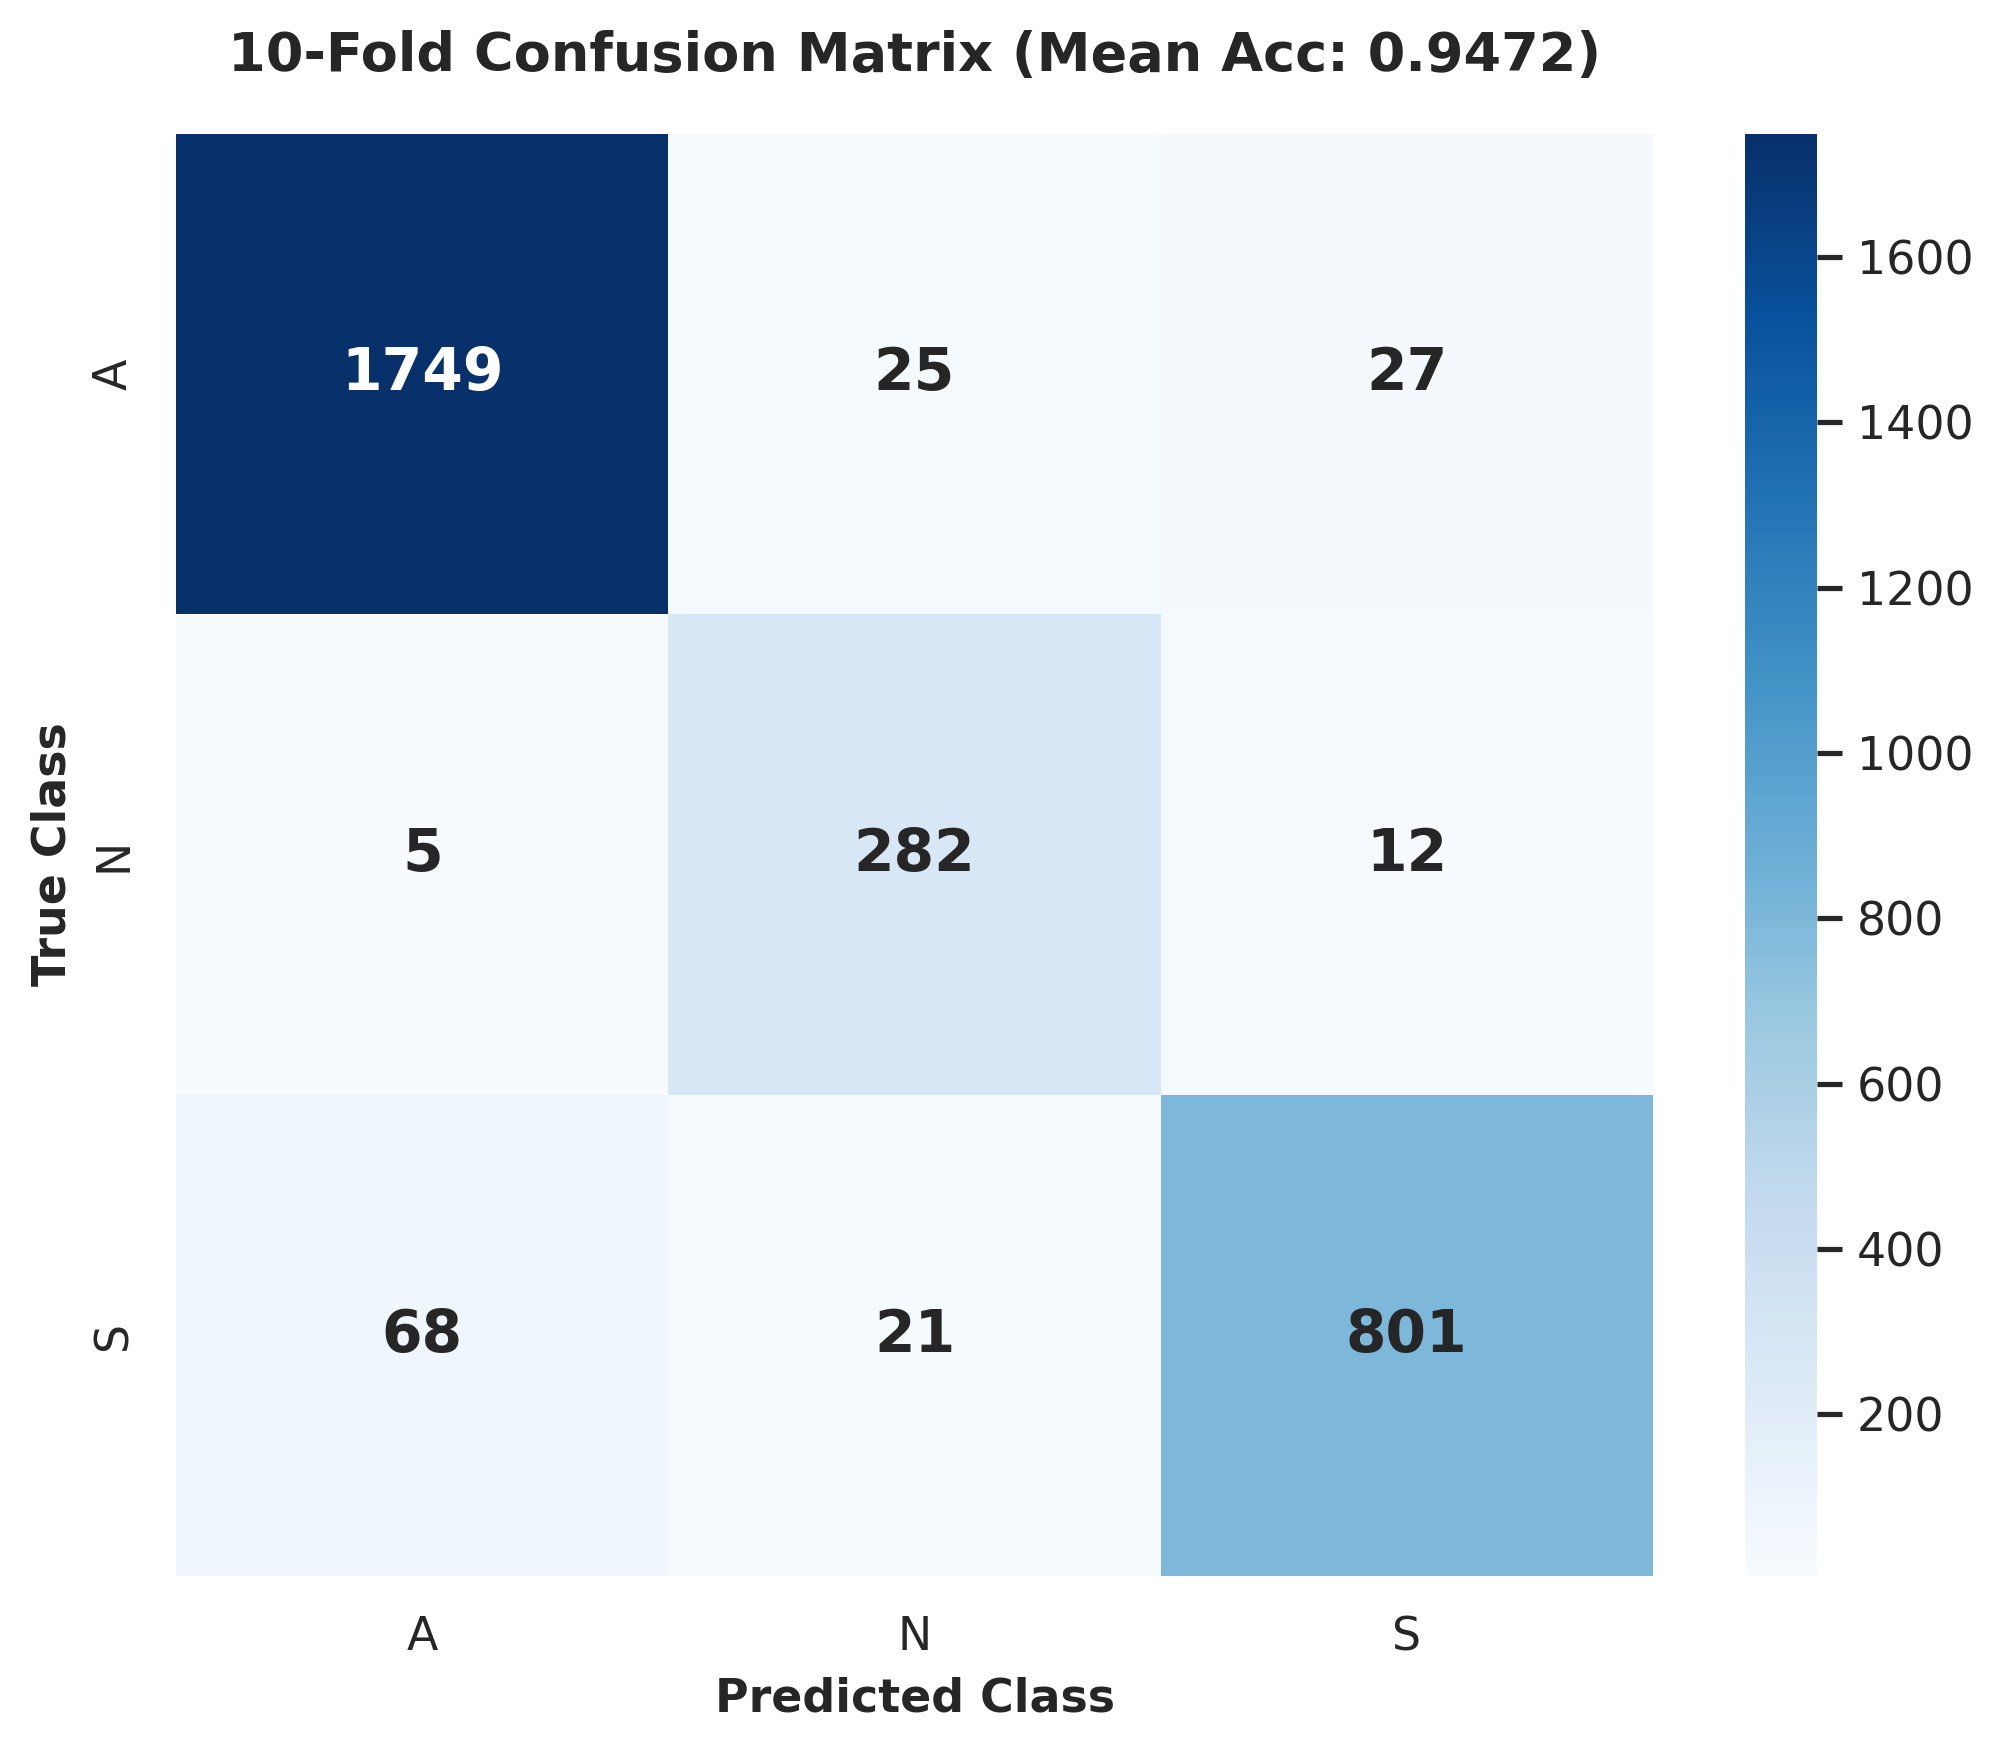

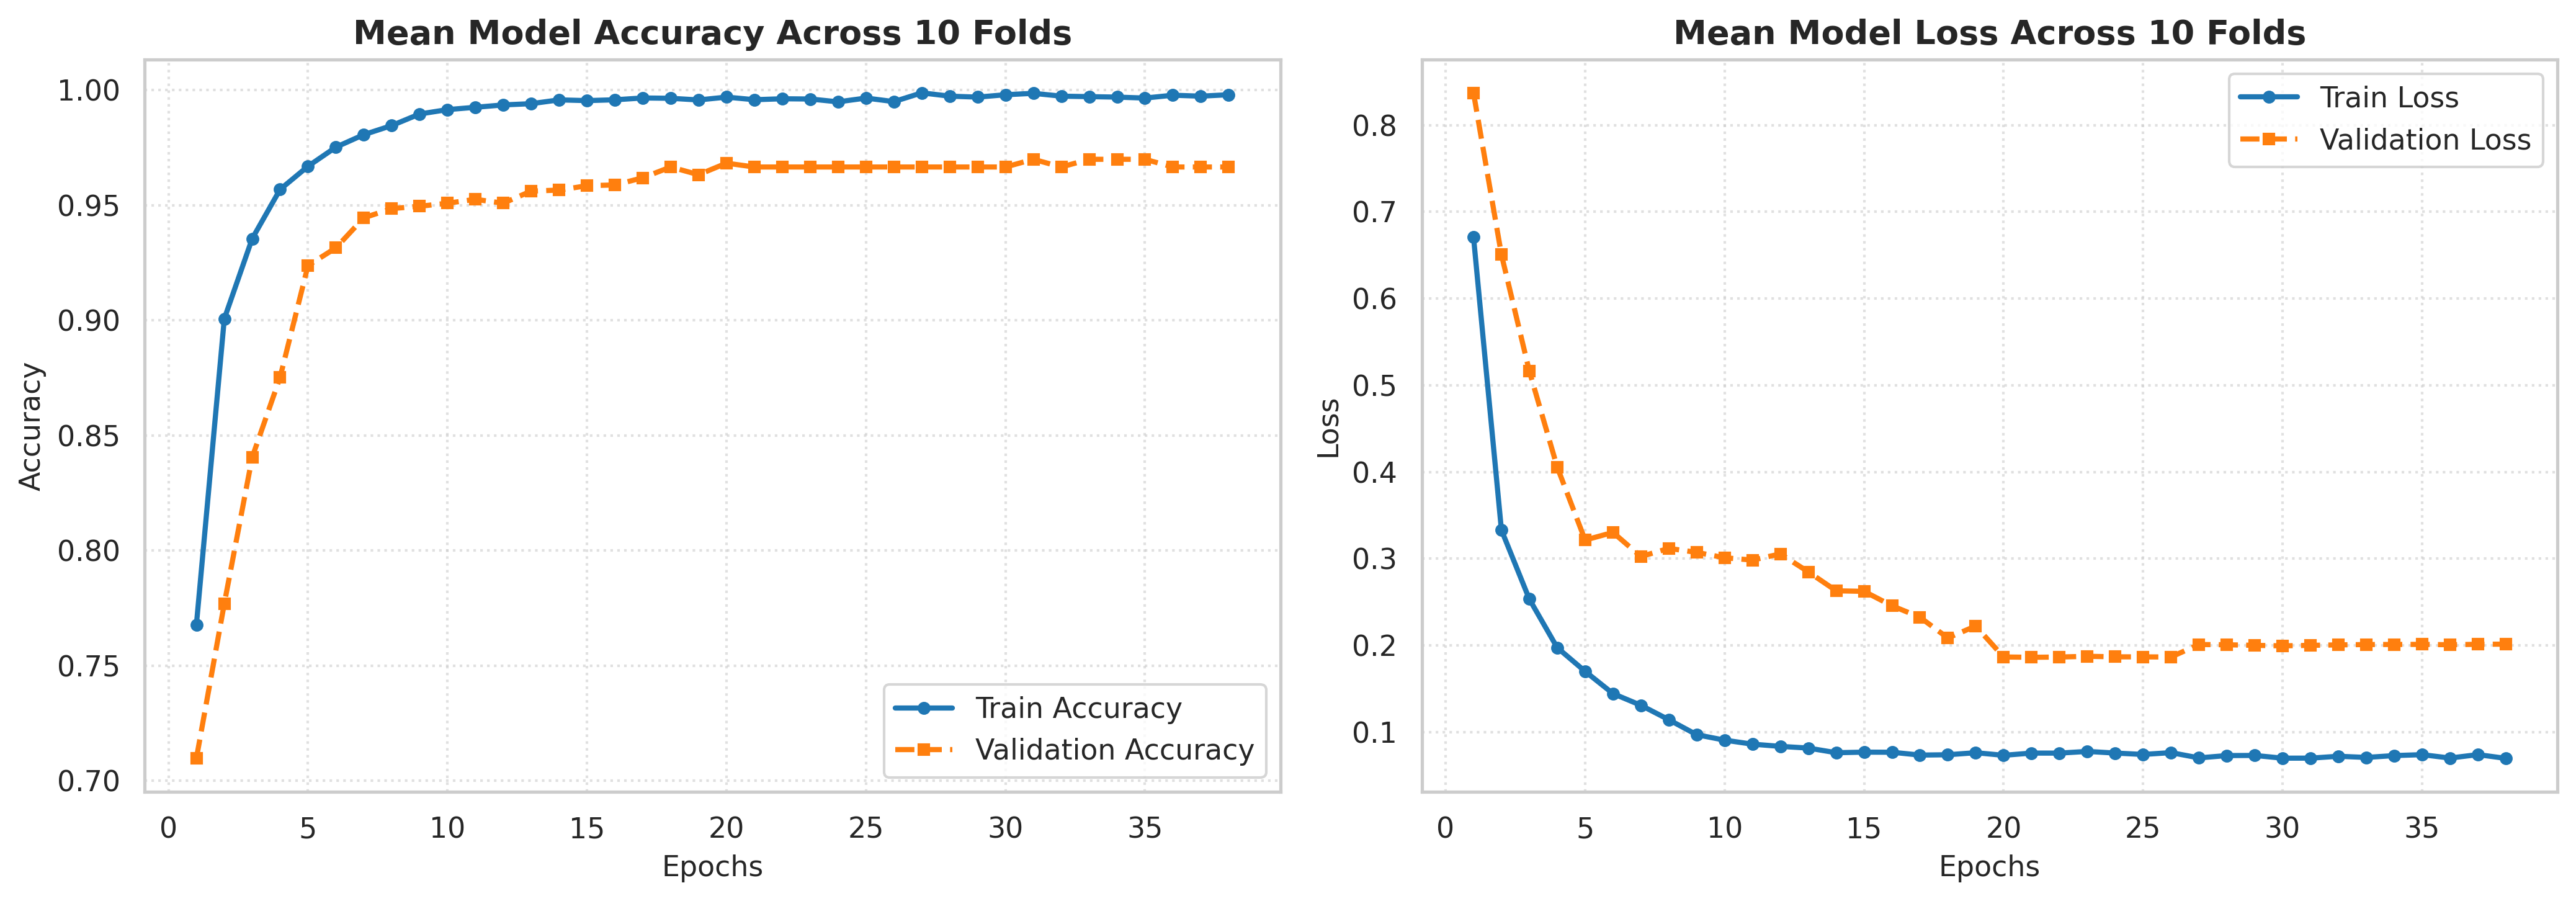

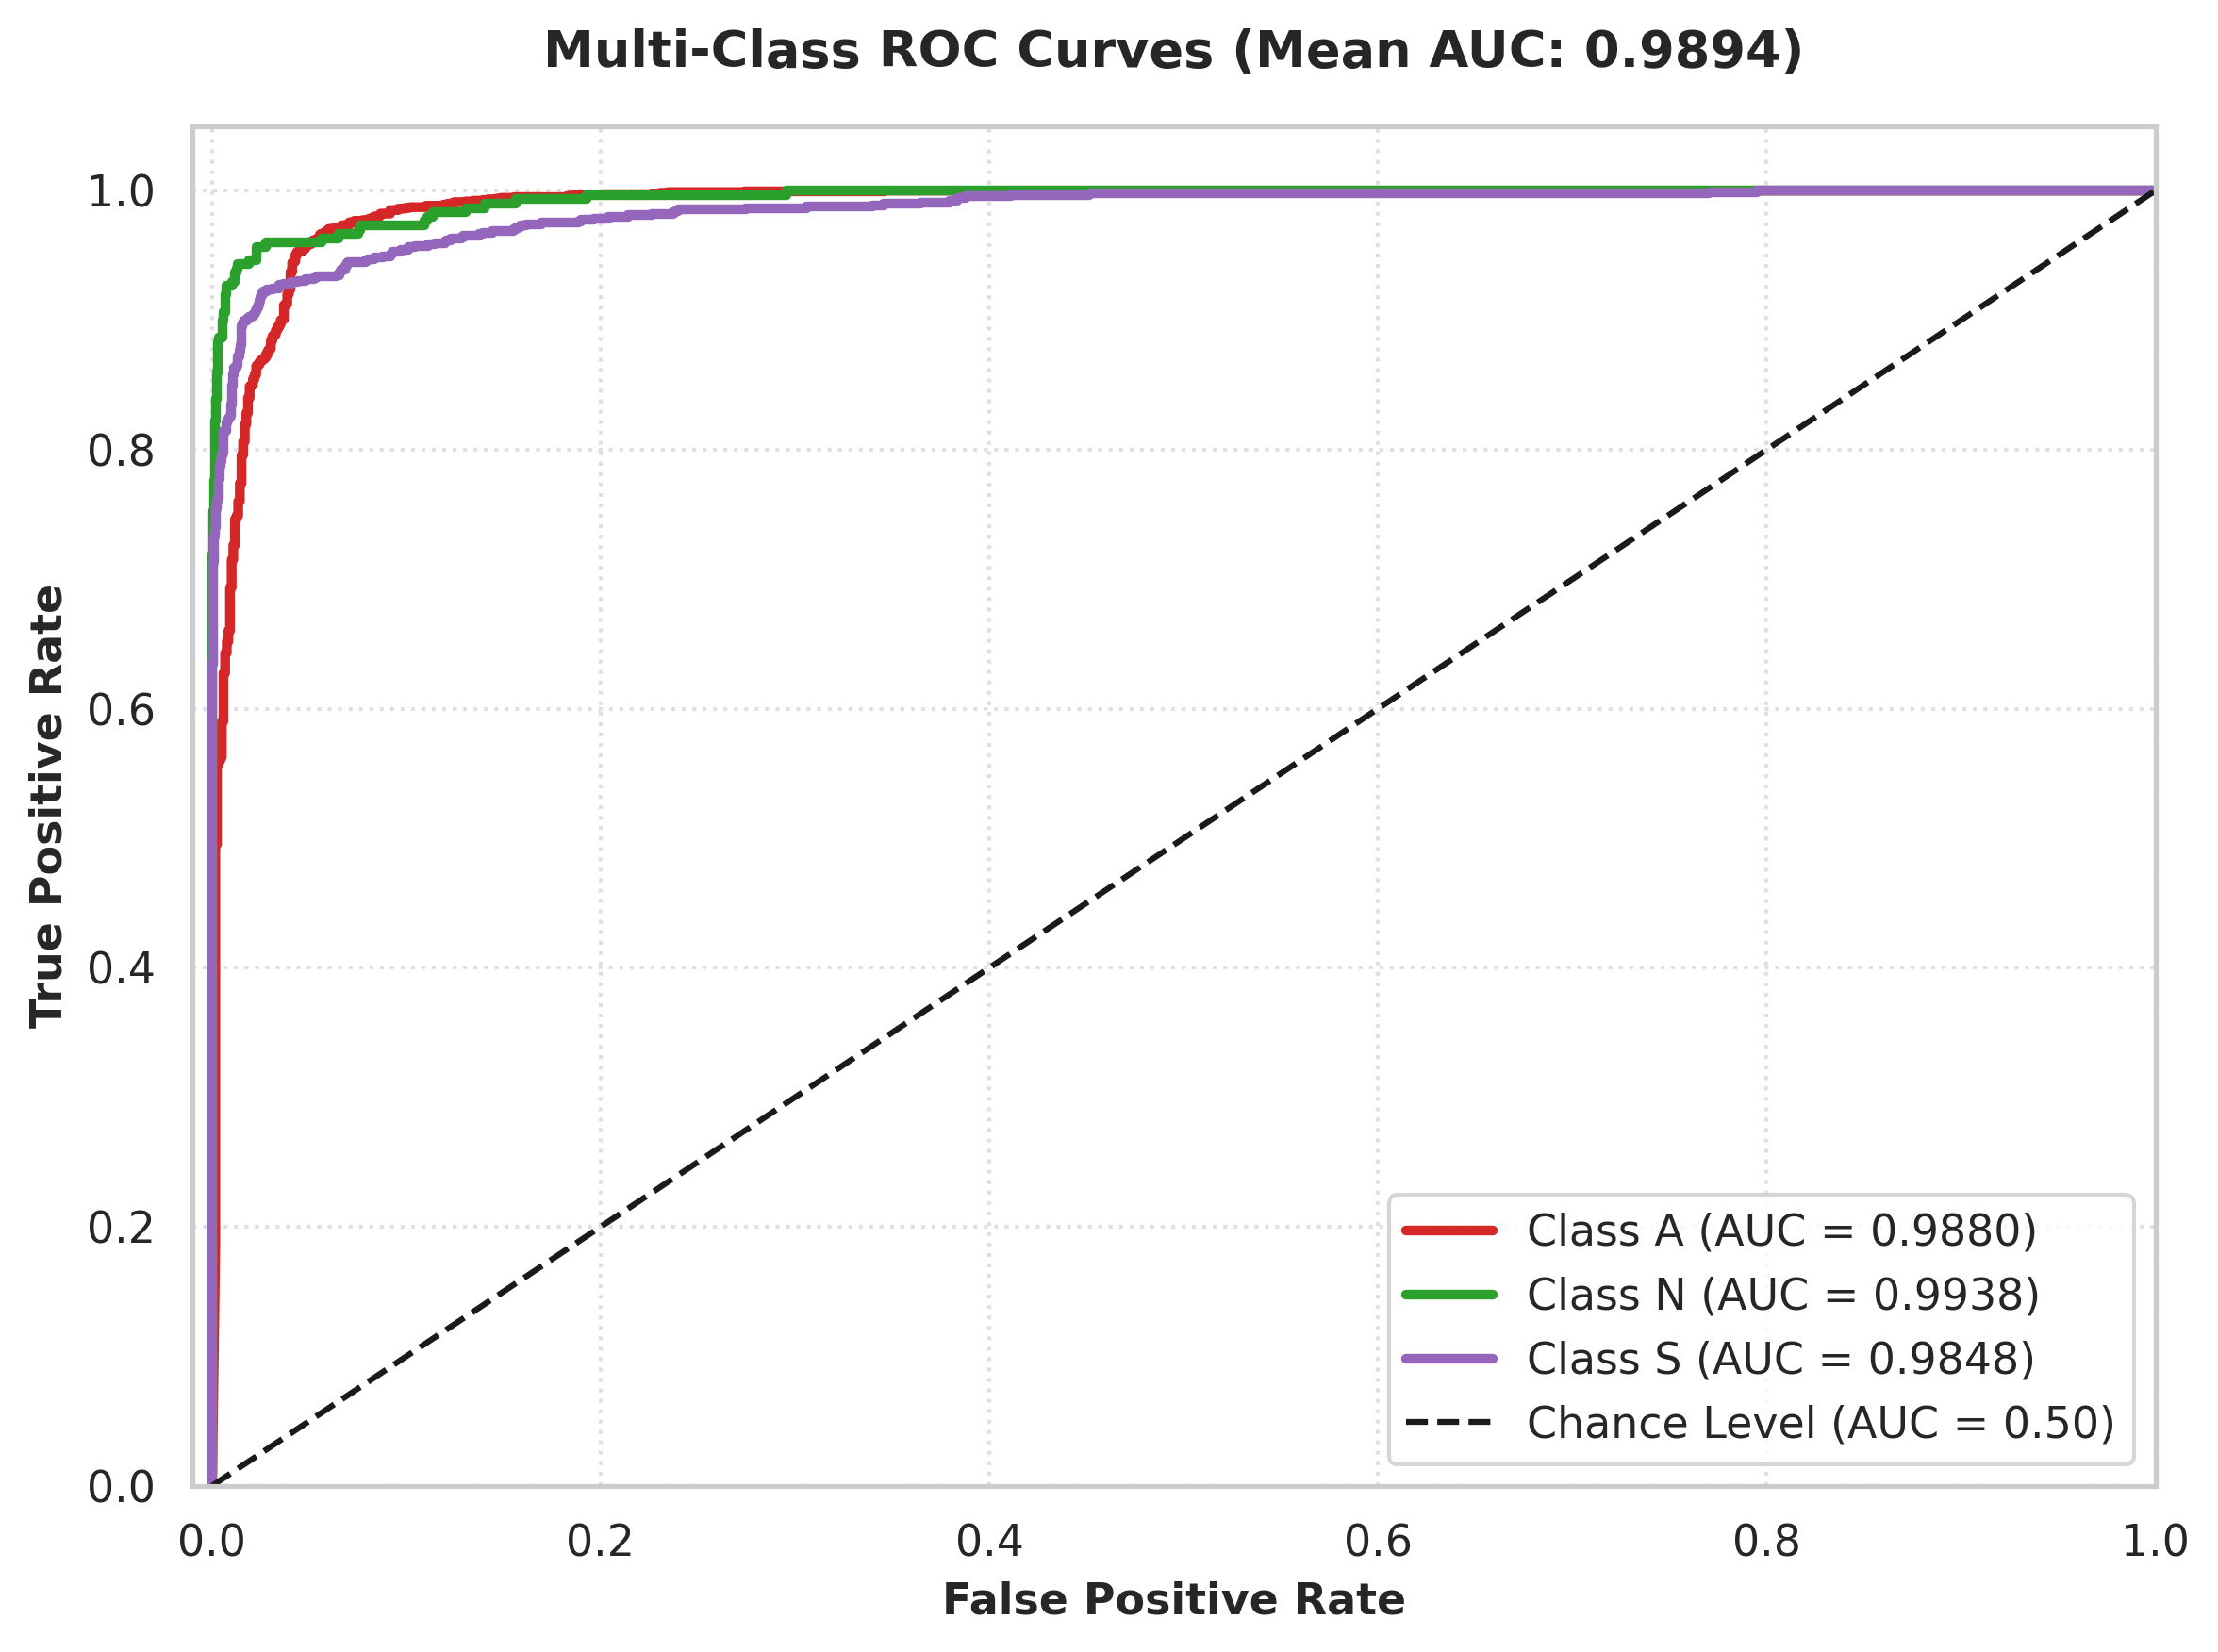

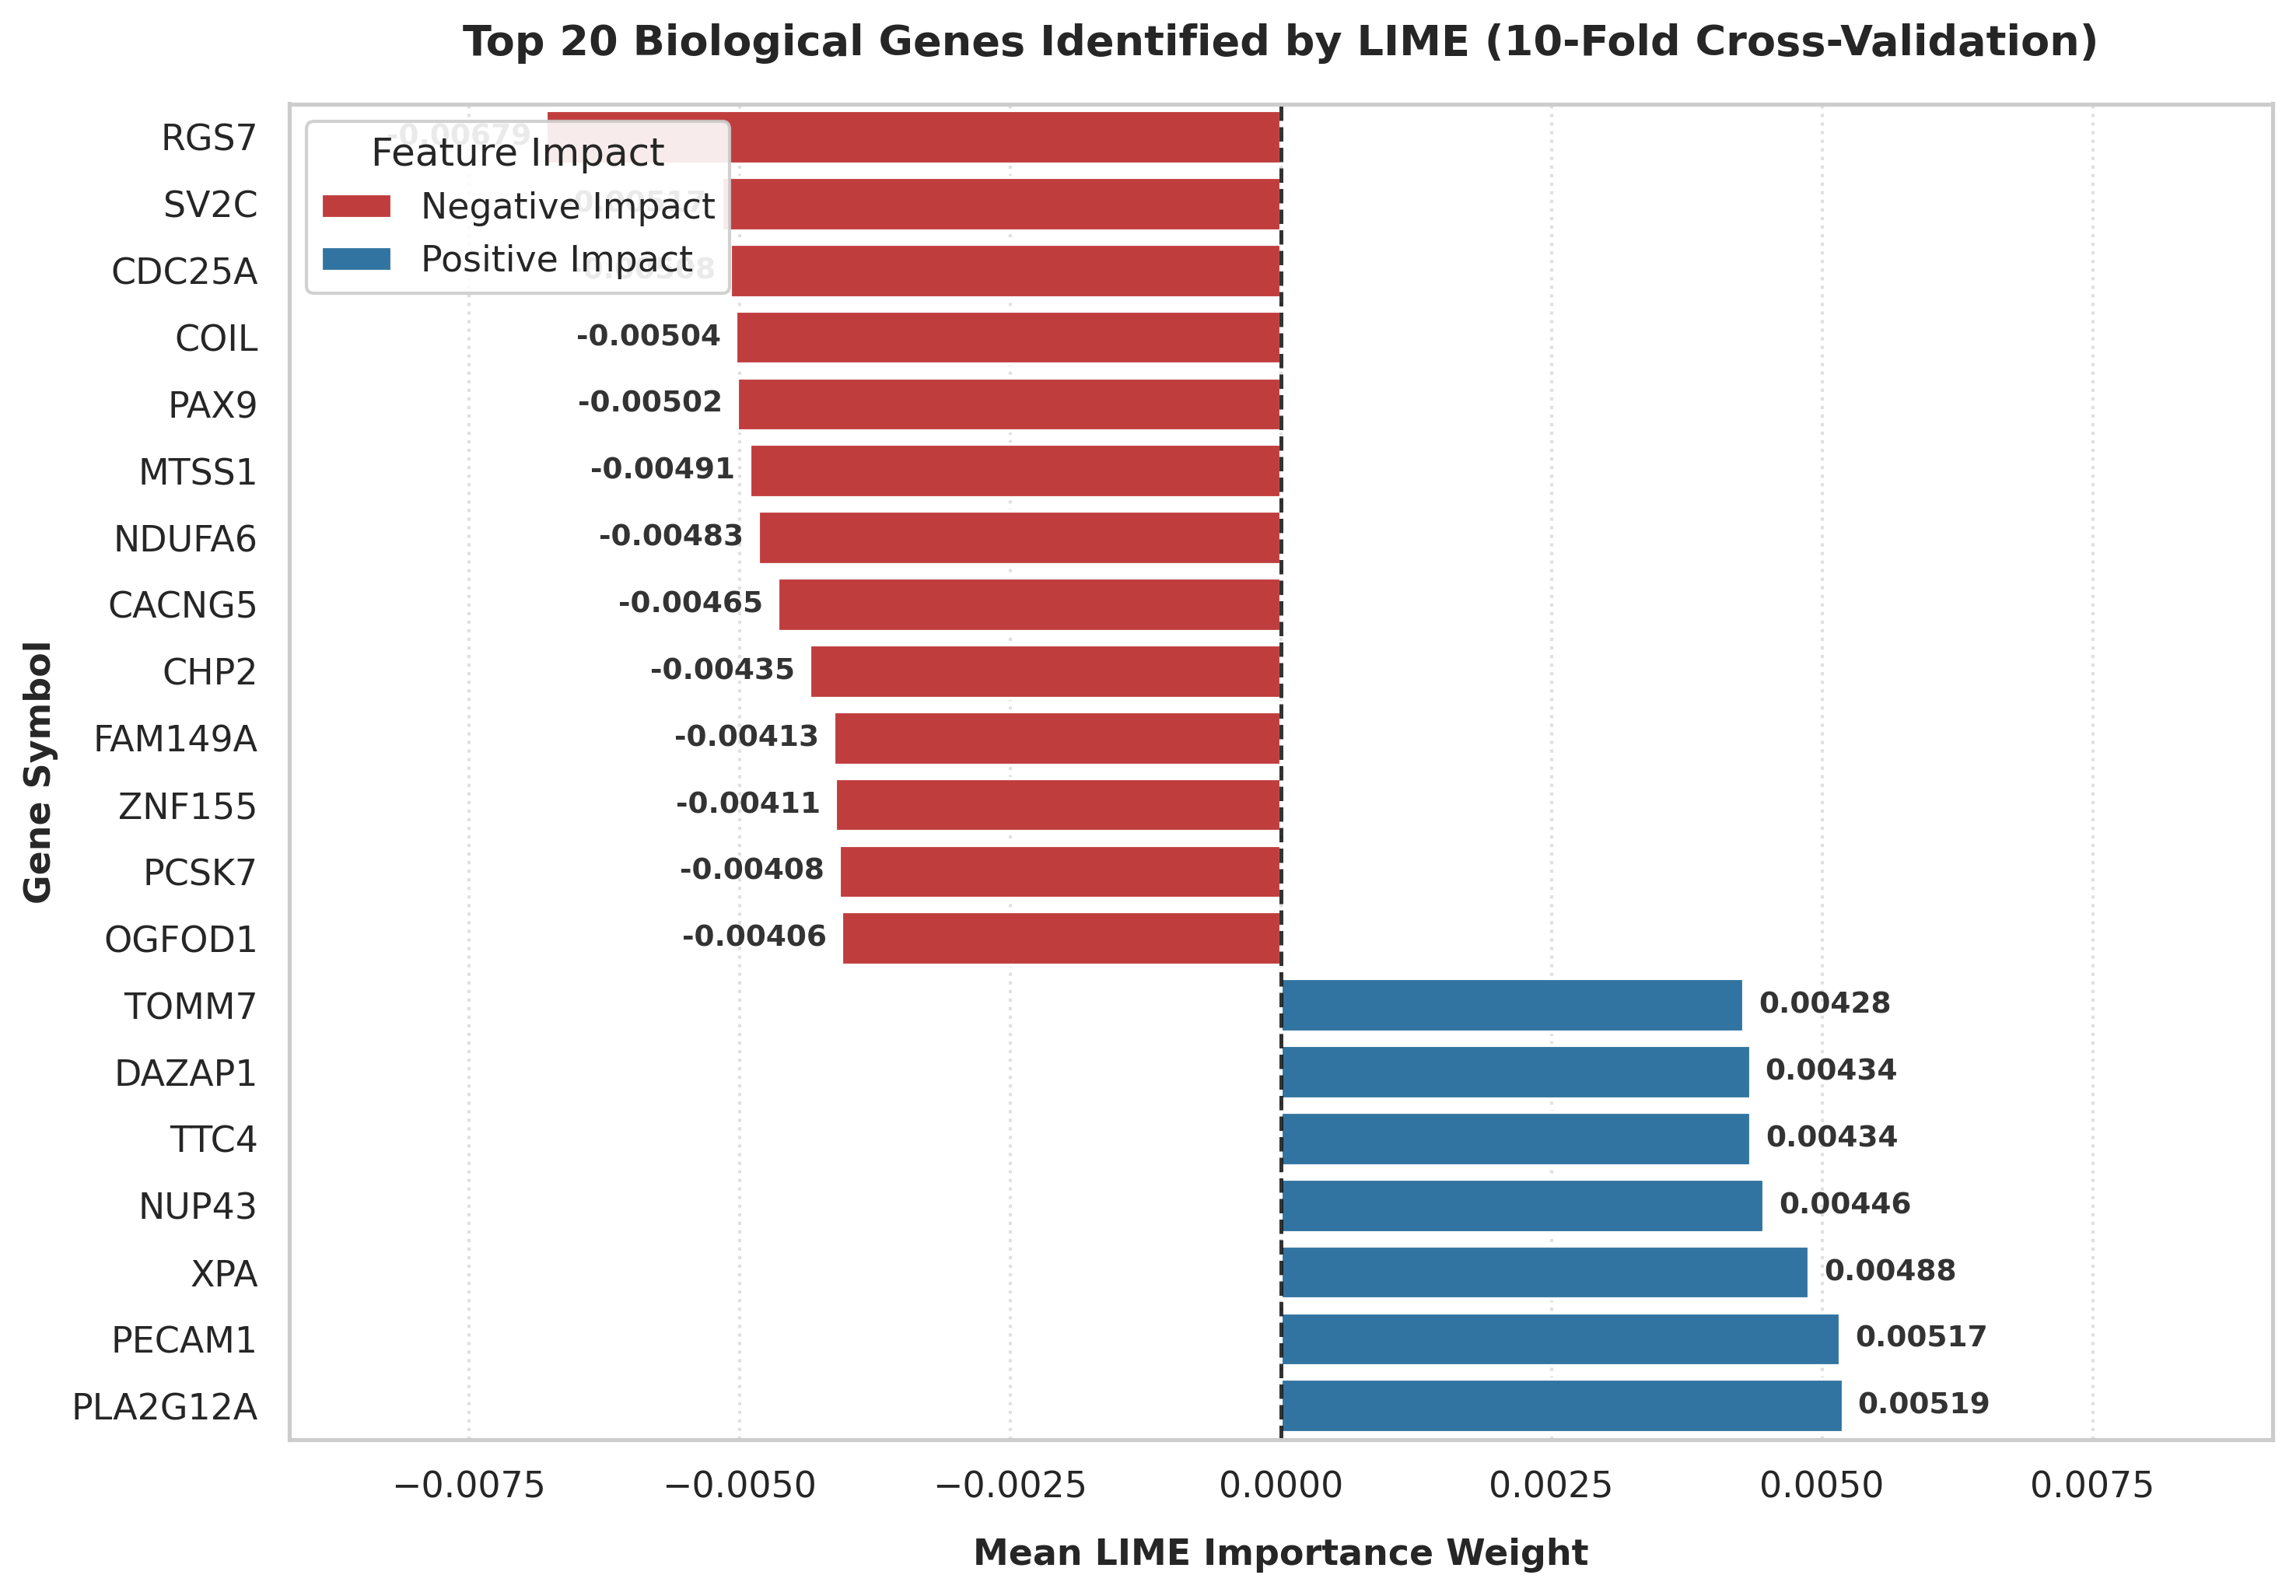

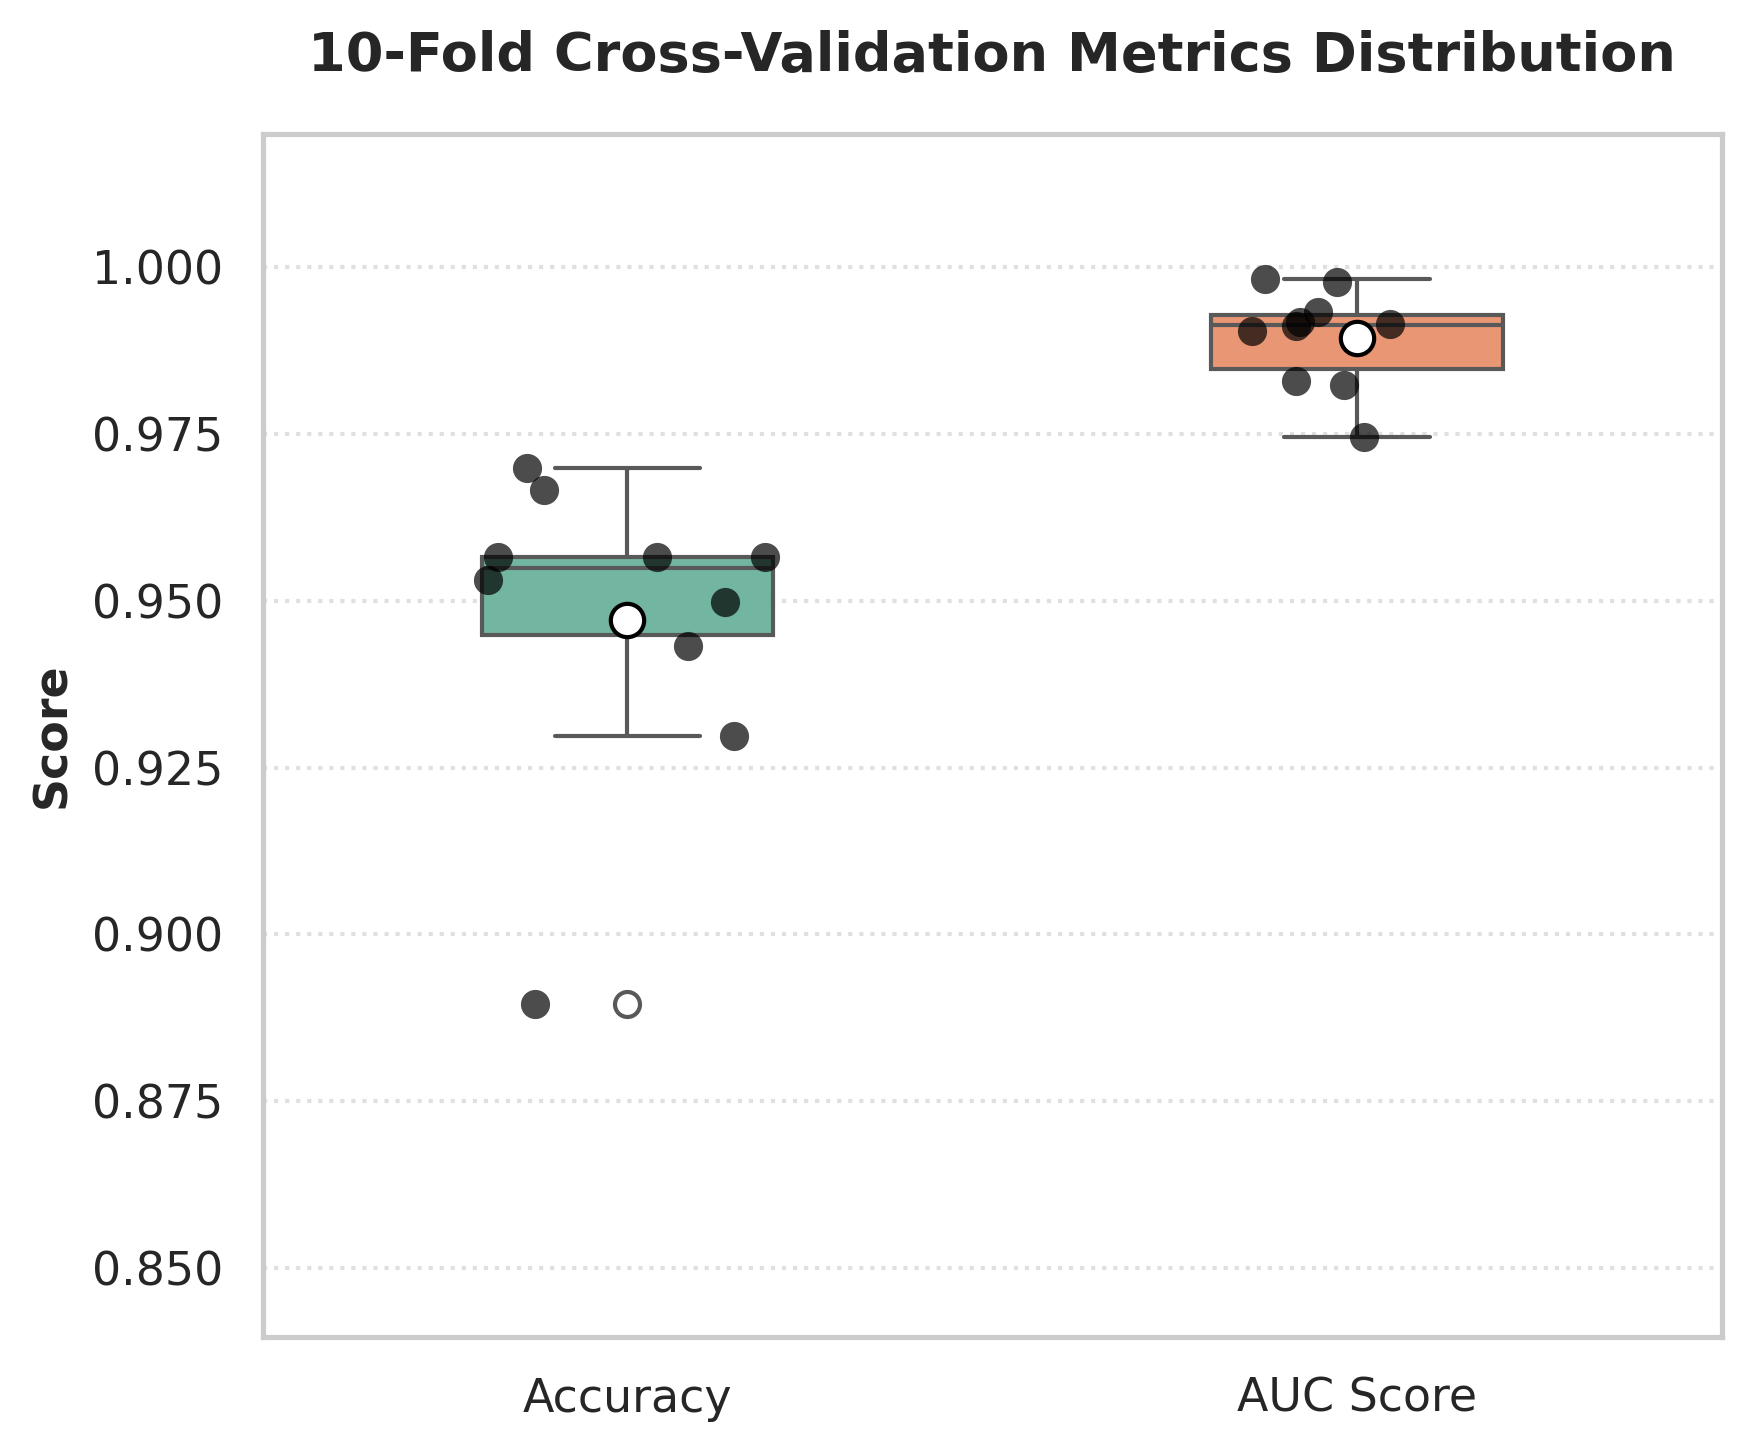


=== Click Links Below to Download Output Files ===

--- CSV Tables ---


/kaggle/working/fold_performance_metrics.csv

/kaggle/working/top_10_genes_direct_lime.csv

/kaggle/working/top_100_genes_direct_lime.csv

/kaggle/working/all_genes_ranked_direct_lime.csv

...

/kaggle/working/confusion_matrix_direct.png

/kaggle/working/learning_curves_direct.png

/kaggle/working/roc_curves_direct.png

/kaggle/working/top_20_genes_lime_direct.png

/kaggle/working/fold_performance_distribution.png

In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from IPython.display import FileLink, display

# -------------------------------------------------------------------
# 1. Load Pre-Computed Cross-Validation Data
# -------------------------------------------------------------------
data = np.load('model_10fold_results_and_history_no_pca.npz', allow_pickle=True)

all_y_true = data['y_true']
all_y_pred_probs = data['y_pred_probs']
all_y_pred_classes = data['y_pred_classes']
fold_auc_scores = data['fold_auc_scores']
fold_acc_scores = data['fold_acc_scores']
all_fold_gene_importances = data['gene_importances']
gene_cols = data['gene_names']
class_names = data['class_names']
all_histories = json.loads(str(data['histories_json']))

print("="*50)
print("=== EVALUATION SUMMARY ===")
print("="*50)
print(f"Mean Accuracy: {np.mean(fold_acc_scores):.4f} ± {np.std(fold_acc_scores):.4f}")
print(f"Mean AUC:      {np.mean(fold_auc_scores):.4f} ± {np.std(fold_auc_scores):.4f}")

# -------------------------------------------------------------------
# 2. Export CSV Tables
# -------------------------------------------------------------------
# Table 1: Fold-by-Fold Performance Metrics
fold_summary_df = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(len(fold_acc_scores))],
    'Accuracy': fold_acc_scores,
    'AUC': fold_auc_scores
})
fold_summary_df.loc['Mean'] = ['Mean', np.mean(fold_acc_scores), np.mean(fold_auc_scores)]
fold_summary_df.loc['Std'] = ['Std', np.std(fold_acc_scores), np.std(fold_auc_scores)]
fold_summary_df.to_csv('fold_performance_metrics.csv', index=False)

# Table 2: Ranked Gene Feature Importance (LIME)
mean_gene_importance = np.mean(all_fold_gene_importances, axis=0)
overall_gene_ranking = pd.DataFrame({
    'Gene': gene_cols,
    'Mean_Importance_Score': mean_gene_importance,
    'Abs_Mean_Importance': np.abs(mean_gene_importance)
}).sort_values(by='Abs_Mean_Importance', ascending=False).reset_index(drop=True)

overall_gene_ranking.head(10).to_csv('top_10_genes_direct_lime.csv', index=False)
overall_gene_ranking.head(100).to_csv('top_100_genes_direct_lime.csv', index=False)
overall_gene_ranking.to_csv('all_genes_ranked_direct_lime.csv', index=False)

# -------------------------------------------------------------------
# 3. Generate & Export Publication Figures (300 DPI)
# -------------------------------------------------------------------
sns.set_theme(style="whitegrid")

# ===================================================================
# Figure 1: Confusion Matrix
# ===================================================================
cm = confusion_matrix(all_y_true, all_y_pred_classes)
plt.figure(figsize=(7, 6), dpi=300)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names,
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title(f'10-Fold Confusion Matrix (Mean Acc: {np.mean(fold_acc_scores):.4f})', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted Class', fontsize=11, fontweight='bold')
plt.ylabel('True Class', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_direct.png', dpi=300)
plt.show()

# ===================================================================
# Figure 2: Learning & Loss Curves
# ===================================================================
max_ep = max([len(h['accuracy']) for h in all_histories])

def get_masked_metric_mean(metric_name):
    matrix = np.full((len(all_histories), max_ep), np.nan)
    for i, h in enumerate(all_histories):
        matrix[i, :len(h[metric_name])] = h[metric_name]
    return np.nanmean(matrix, axis=0)

mean_train_acc = get_masked_metric_mean('accuracy')
mean_val_acc = get_masked_metric_mean('val_accuracy')
mean_train_loss = get_masked_metric_mean('loss')
mean_val_loss = get_masked_metric_mean('val_loss')

epochs_range = range(1, max_ep + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# Accuracy Subplot
ax1.plot(epochs_range, mean_train_acc, 'o-', label='Train Accuracy', color='#1f77b4', lw=2, markersize=4)
ax1.plot(epochs_range, mean_val_acc, 's--', label='Validation Accuracy', color='#ff7f0e', lw=2, markersize=4)
ax1.set_title('Mean Model Accuracy Across 10 Folds', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.legend(loc='lower right', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)

# Loss Subplot
ax2.plot(epochs_range, mean_train_loss, 'o-', label='Train Loss', color='#1f77b4', lw=2, markersize=4)
ax2.plot(epochs_range, mean_val_loss, 's--', label='Validation Loss', color='#ff7f0e', lw=2, markersize=4)
ax2.set_title('Mean Model Loss Across 10 Folds', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('learning_curves_direct.png', dpi=300)
plt.show()

# ===================================================================
# Figure 3: Multi-Class ROC Curves
# ===================================================================
plt.figure(figsize=(8, 6), dpi=300)
colors = ['#d62728', '#2ca02c', '#9467bd', '#17becf', '#e377c2']

for i, class_name in enumerate(class_names):
    y_true_binary = (all_y_true == i).astype(int)
    fpr, tpr, _ = roc_curve(y_true_binary, all_y_pred_probs[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(
        fpr, tpr, 
        color=colors[i % len(colors)], 
        lw=2.5,
        label=f'Class {class_name} (AUC = {roc_auc_val:.4f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Chance Level (AUC = 0.50)')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=11, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=11, fontweight='bold')
plt.title(f'Multi-Class ROC Curves (Mean AUC: {np.mean(fold_auc_scores):.4f})', fontsize=13, fontweight='bold', pad=15)
plt.legend(loc="lower right", frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('roc_curves_direct.png', dpi=300)
plt.show()

# ===================================================================
# Figure 4: Enhanced Top 20 Gene Features (Directional LIME Bar Plot)
# ===================================================================
top_n = 20

# Top 20 genes sorted by signed weight
top_genes_df = overall_gene_ranking.head(top_n).copy()
top_genes_df = top_genes_df.sort_values(by='Mean_Importance_Score', ascending=True)

# Assign distinct color categories for positive vs negative weights
top_genes_df['Impact'] = np.where(top_genes_df['Mean_Importance_Score'] > 0, 'Positive Impact', 'Negative Impact')
color_palette = {'Positive Impact': '#1f77b4', 'Negative Impact': '#d62728'}

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

bars = sns.barplot(
    data=top_genes_df,
    x='Mean_Importance_Score',
    y='Gene',
    hue='Impact',
    palette=color_palette,
    dodge=False,
    ax=ax
)

# Reference axis line at x = 0
ax.axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)

# Exact numeric value annotations next to each bar
for p in bars.patches:
    val = p.get_width()
    if not np.isnan(val) and val != 0:
        y_pos = p.get_y() + p.get_height() / 2.0
        if val > 0:
            x_pos = val + (top_genes_df['Abs_Mean_Importance'].max() * 0.02)
            ha = 'left'
        else:
            x_pos = val - (top_genes_df['Abs_Mean_Importance'].max() * 0.02)
            ha = 'right'
            
        ax.text(x_pos, y_pos, f'{val:.5f}', va='center', ha=ha, fontsize=9, fontweight='semibold', color='#333333')

ax.set_title(f'Top {top_n} Biological Genes Identified by LIME (10-Fold Cross-Validation)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Mean LIME Importance Weight', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Gene Symbol', fontsize=11, fontweight='bold')

# Adjust x-axis limits to leave room for value annotations
x_max = top_genes_df['Abs_Mean_Importance'].max() * 1.35
ax.set_xlim(-x_max, x_max)

ax.legend(title='Feature Impact', loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax.grid(True, linestyle=':', alpha=0.6, axis='x')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('top_20_genes_lime_direct.png', dpi=300)
plt.show()

# ===================================================================
# Figure 5: 10-Fold Performance Distribution Boxplot
# ===================================================================
metrics_df = pd.DataFrame({
    'Accuracy': fold_acc_scores,
    'AUC Score': fold_auc_scores
})

plt.figure(figsize=(6, 5), dpi=300)
sns.boxplot(
    data=metrics_df, 
    palette='Set2', 
    width=0.4, 
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)
sns.stripplot(data=metrics_df, color='black', alpha=0.7, jitter=0.2, size=7)
plt.title('10-Fold Cross-Validation Metrics Distribution', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Score', fontsize=11, fontweight='bold')
plt.ylim([min(min(fold_acc_scores), min(fold_auc_scores)) - 0.05, 1.02])
plt.grid(True, linestyle=':', alpha=0.6, axis='y')
plt.tight_layout()
plt.savefig('fold_performance_distribution.png', dpi=300)
plt.show()

# -------------------------------------------------------------------
# 4. Download Links for All CSV Tables and Figures
# -------------------------------------------------------------------
print("\n=== Click Links Below to Download Output Files ===")

print("\n--- CSV Tables ---")
display(FileLink('fold_performance_metrics.csv'))
display(FileLink('top_10_genes_direct_lime.csv'))
display(FileLink('top_100_genes_direct_lime.csv'))
display(FileLink('all_genes_ranked_direct_lime.csv'))

print("\n--- Publication Figures (300 DPI) ---")
display(FileLink('confusion_matrix_direct.png'))
display(FileLink('learning_curves_direct.png'))
display(FileLink('roc_curves_direct.png'))
display(FileLink('top_20_genes_lime_direct.png'))
display(FileLink('fold_performance_distribution.png'))

# # Comparing our model with the other Popular models for gene expression data 

✅ Running DL models on GPU: /physical_device:GPU:0
Dataset Loaded | Train Samples (SMOTE): 4323 | Test Samples: 598 | Genes: 11494

[1/6] Training Random Forest...
 -> Random Forest          | Acc: 0.9080 | AUC: 0.9835 | F1: 0.9062 | Kappa: 0.8220
[2/6] Training SVM (RBF Kernel)...
 -> SVM (RBF)              | Acc: 0.9181 | AUC: 0.9829 | F1: 0.9164 | Kappa: 0.8441
[3/6] Training Extra Trees Classifier...
 -> Extra Trees            | Acc: 0.8829 | AUC: 0.9800 | F1: 0.8796 | Kappa: 0.7705
[4/6] Training Logistic Regression (L1 Regularized)...
 -> Logistic Regression    | Acc: 0.6304 | AUC: 0.7716 | F1: 0.6359 | Kappa: 0.3299
[5/6] Training MLP (Deep Neural Network)...
 -> MLP (Deep Network)     | Acc: 0.9281 | AUC: 0.9850 | F1: 0.9277 | Kappa: 0.8655
[6/6] Loading Pre-Computed Proposed 1D-CNN Results...
 -> Proposed 1D-CNN        | Acc: 0.9472 | AUC: 0.9889 | F1: 0.9471 | Kappa: 0.9018

=== COMPREHENSIVE BENCHMARK EVALUATION ===
              Model  Accuracy  ROC-AUC  Precision   Recall 

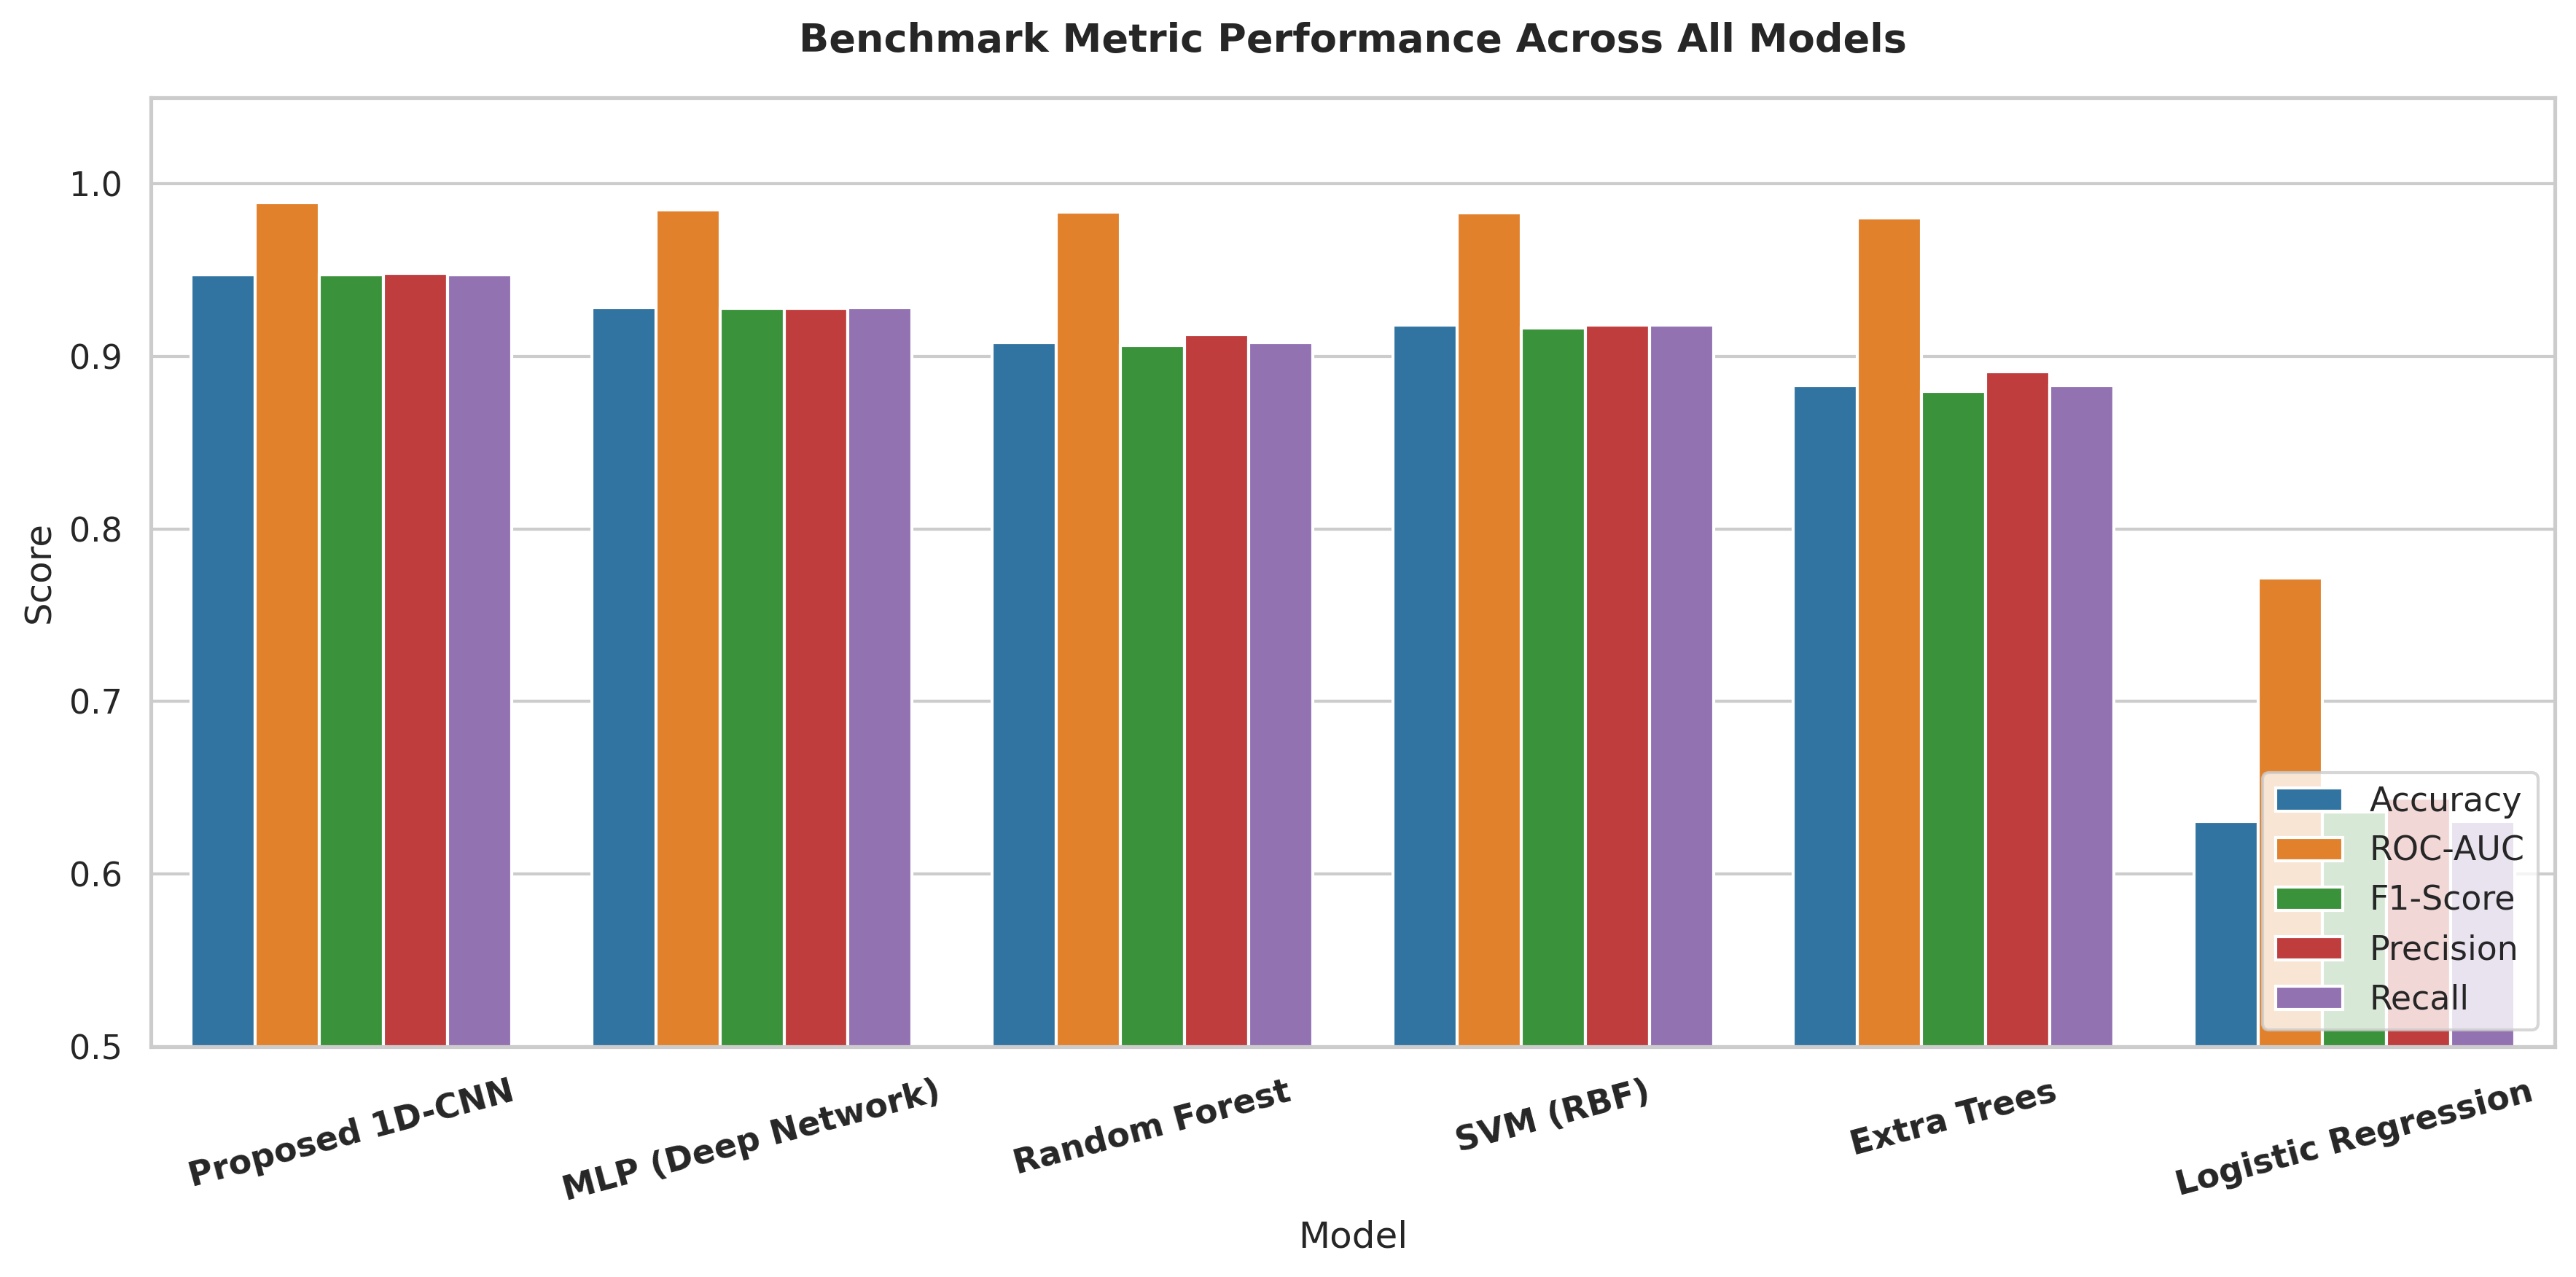

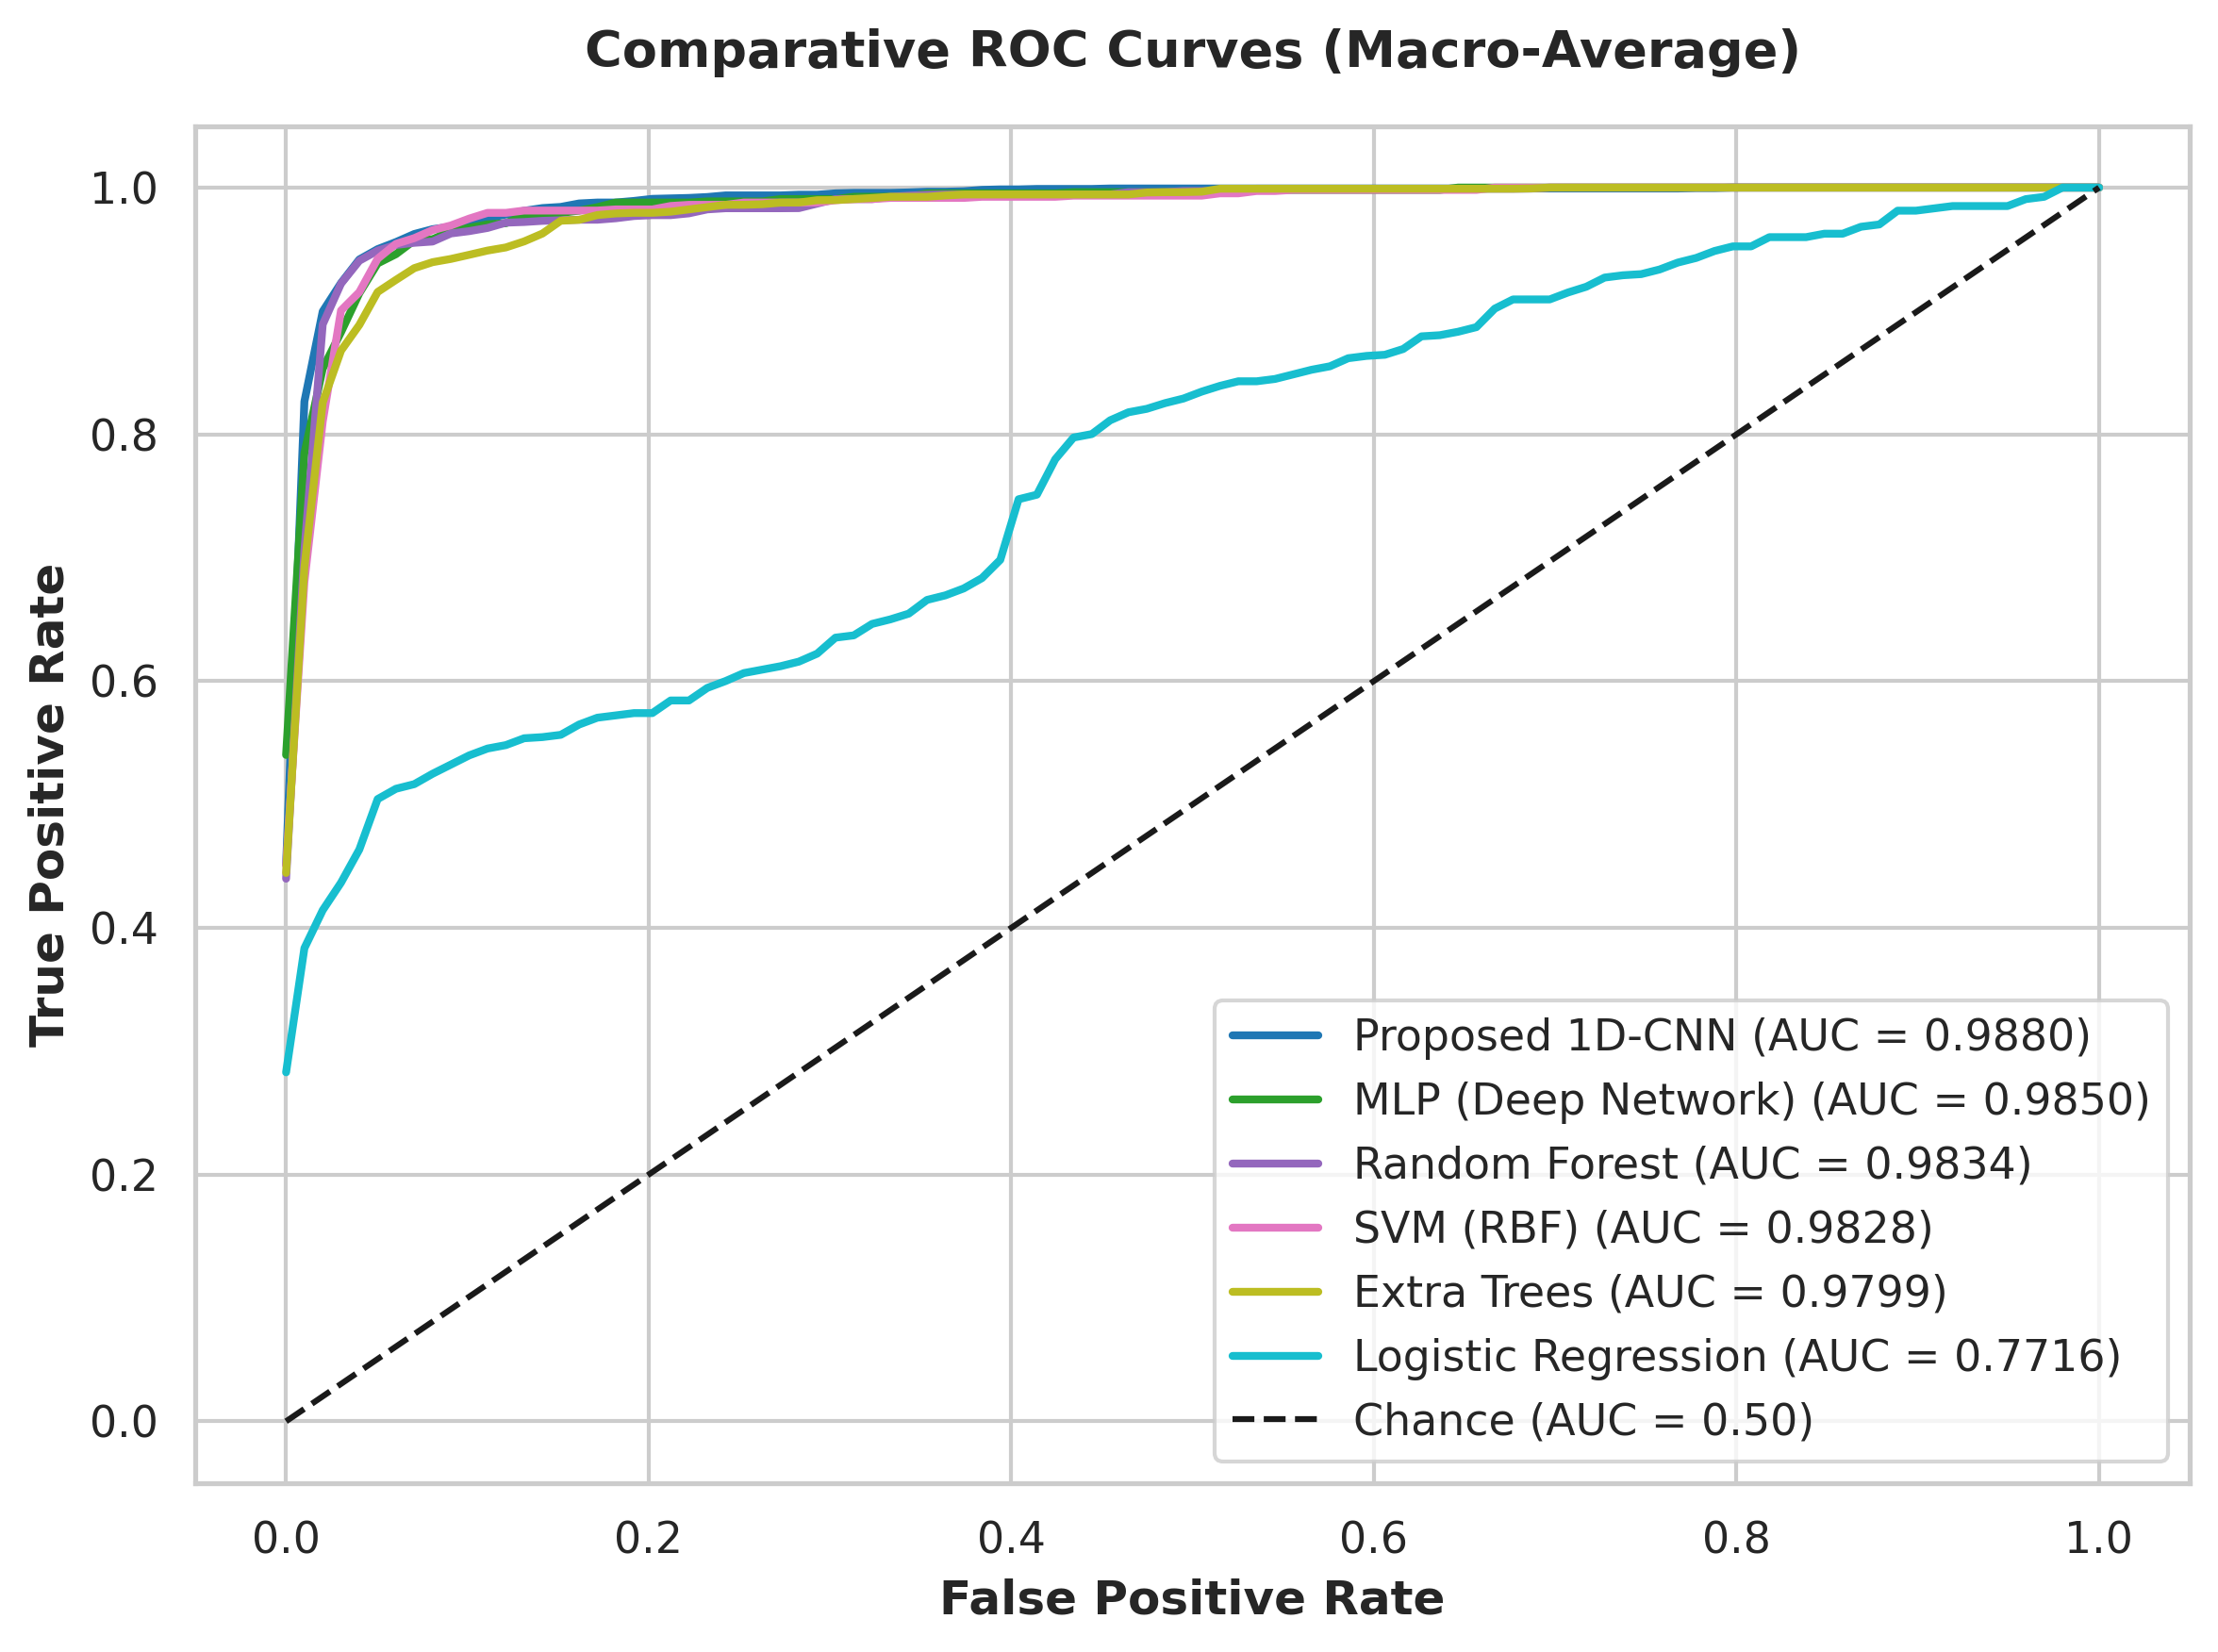

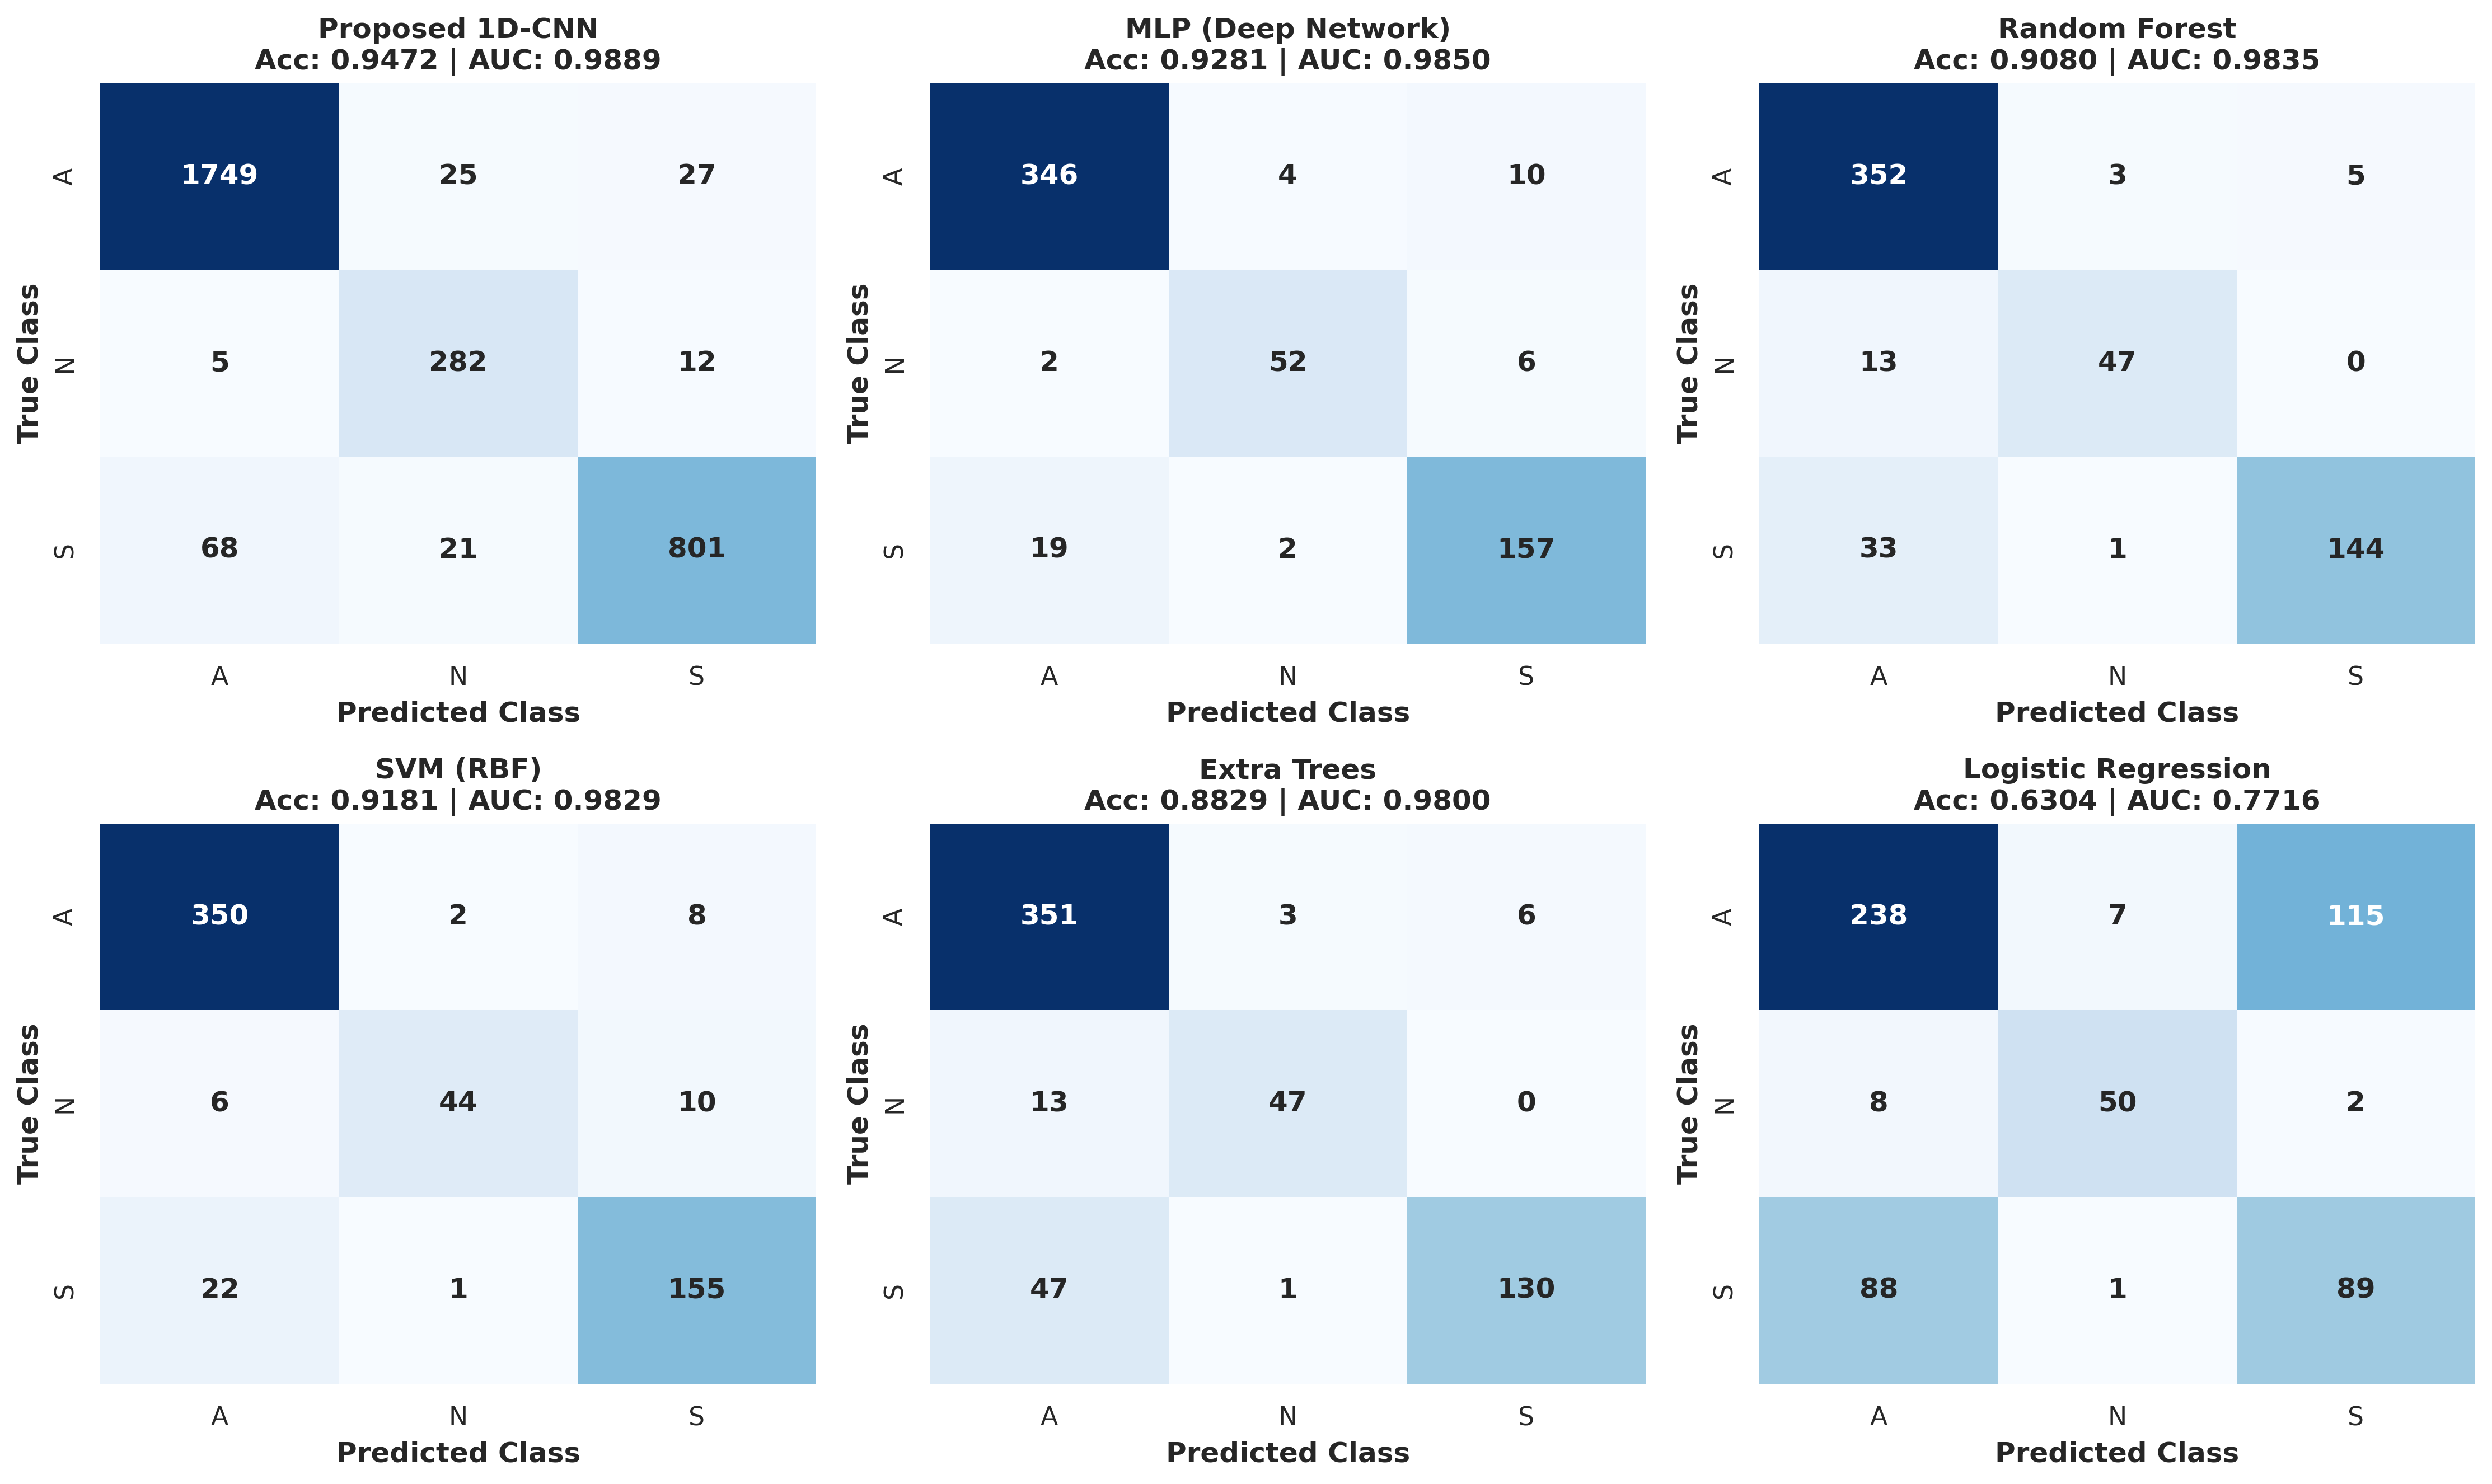

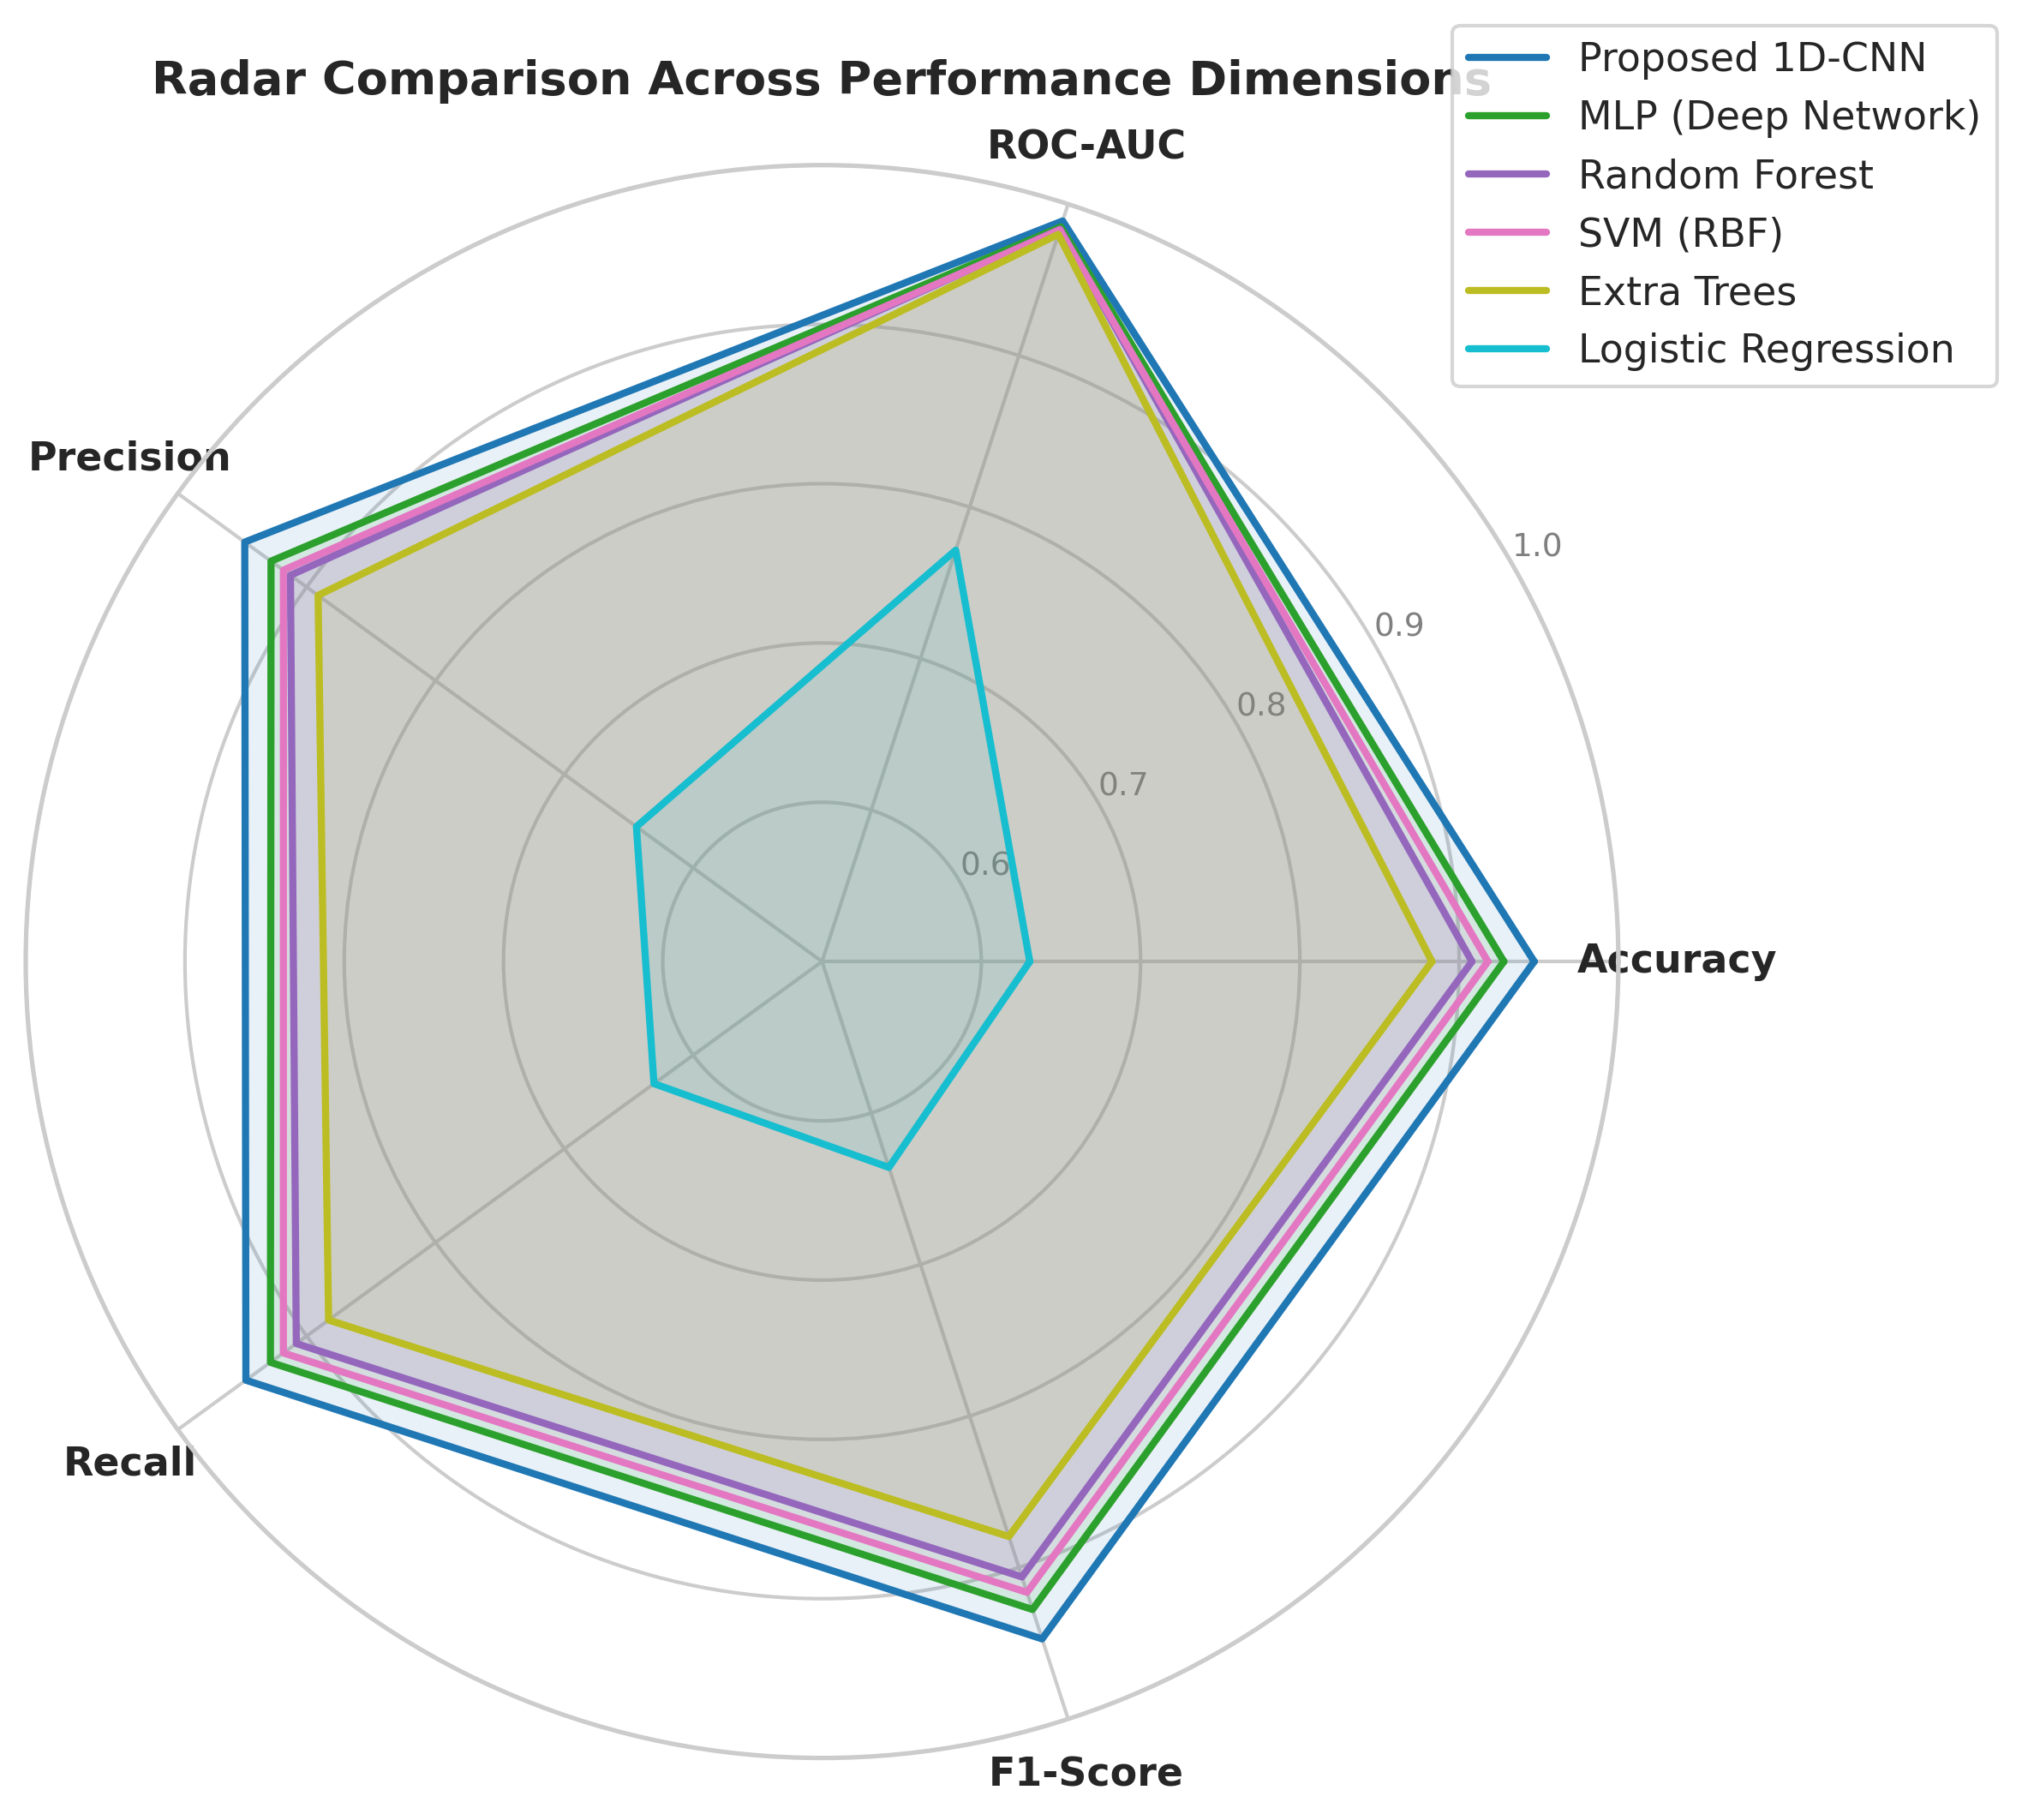


=== Click Links Below to Download Benchmark Output Files ===

--- CSV Tables ---


/kaggle/working/model_benchmark_extended_metrics.csv

/kaggle/working/model_per_class_performance.csv


--- Publication Figures (300 DPI) ---


/kaggle/working/benchmark_metrics_bar_chart.png

/kaggle/working/comparative_roc_curves.png

/kaggle/working/all_models_confusion_matrices.png

/kaggle/working/radar_chart_comparison.png

In [5]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------
# 0. Suppress Warnings & C++ Logging Streams
# -------------------------------------------------------------------
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

class SuppressStderr:
    def __enter__(self):
        sys.stderr.flush()
        self._err_null = open(os.devnull, 'w')
        self._old_stderr_fd = os.dup(2)
        os.dup2(self._err_null.fileno(), 2)

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stderr.flush()
        os.dup2(self._old_stderr_fd, 2)
        os.close(self._old_stderr_fd)
        self._err_null.close()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix, 
    precision_recall_fscore_support, cohen_kappa_score, 
    roc_curve, auc, classification_report
)

# Machine Learning Classifiers
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Deep Learning Classifiers
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from IPython.display import FileLink, display

# Set Seed for Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.get_logger().setLevel('FATAL')

# -------------------------------------------------------------------
# 1. GPU Setup & Data Loading
# -------------------------------------------------------------------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Running DL models on GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ Running on CPU.")

file_path = '/kaggle/input/datasets/syednaseer111/my-data/merged_combat_corrected.parquet'
df = pd.read_parquet(file_path)

label_encoder = LabelEncoder()
df['Condition_Encoded'] = label_encoder.fit_transform(df['Condition'])

metadata_cols = ['Sample_ID', 'Cohort', 'Condition', 'Condition_Encoded']
gene_cols = [col for col in df.columns if col not in metadata_cols]

X = df[gene_cols].values
y = df['Condition_Encoded'].values

num_genes = len(gene_cols)
num_classes = len(label_encoder.classes_)
class_names = [str(c) for c in label_encoder.classes_]

# -------------------------------------------------------------------
# 2. Train/Test Split & Preprocessing
# -------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Dataset Loaded | Train Samples (SMOTE): {X_train_res.shape[0]} | Test Samples: {X_test_scaled.shape[0]} | Genes: {num_genes}")

# Containers for metrics and outputs
results = []
roc_data = {}
confusion_matrices = {}
classification_reports = {}

# Helper function to compute extended evaluation metrics
def log_metrics(model_name, y_true, y_pred_classes, y_pred_probs):
    acc = accuracy_score(y_true, y_pred_classes)
    
    if num_classes == 2:
        auc_score = roc_auc_score(y_true, y_pred_probs[:, 1])
    else:
        auc_score = roc_auc_score(y_true, y_pred_probs, multi_class='ovr', labels=np.arange(num_classes))
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred_classes, average='weighted')
    kappa = cohen_kappa_score(y_true, y_pred_classes)
    
    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'ROC-AUC': auc_score,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Cohen-Kappa': kappa
    })
    
    roc_data[model_name] = y_pred_probs
    confusion_matrices[model_name] = confusion_matrix(y_true, y_pred_classes)
    classification_reports[model_name] = classification_report(y_true, y_pred_classes, target_names=class_names, output_dict=True)
    
    print(f" -> {model_name:<22} | Acc: {acc:.4f} | AUC: {auc_score:.4f} | F1: {f1:.4f} | Kappa: {kappa:.4f}")

# -------------------------------------------------------------------
# 3. Model 1: Random Forest
# -------------------------------------------------------------------
print("\n[1/6] Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

rf_probs = rf_model.predict_proba(X_test_scaled)
rf_preds = np.argmax(rf_probs, axis=1)
log_metrics('Random Forest', y_test, rf_preds, rf_probs)

# -------------------------------------------------------------------
# 4. Model 2: Support Vector Machine (RBF Kernel)
# -------------------------------------------------------------------
print("[2/6] Training SVM (RBF Kernel)...")
svm_model = SVC(kernel='rbf', probability=True, C=1.0, random_state=SEED)
svm_model.fit(X_train_res, y_train_res)

svm_probs = svm_model.predict_proba(X_test_scaled)
svm_preds = np.argmax(svm_probs, axis=1)
log_metrics('SVM (RBF)', y_test, svm_preds, svm_probs)

# -------------------------------------------------------------------
# 5. Model 3: Extra Trees Classifier
# -------------------------------------------------------------------
print("[3/6] Training Extra Trees Classifier...")
et_model = ExtraTreesClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
et_model.fit(X_train_res, y_train_res)

et_probs = et_model.predict_proba(X_test_scaled)
et_preds = np.argmax(et_probs, axis=1)
log_metrics('Extra Trees', y_test, et_preds, et_probs)

# -------------------------------------------------------------------
# 6. Model 4: Sparse Logistic Regression (L1 Penalty)
# -------------------------------------------------------------------
print("[4/6] Training Logistic Regression (L1 Regularized)...")
lr_model = LogisticRegression(penalty='l1', solver='saga', C=0.1, max_iter=500, random_state=SEED)
lr_model.fit(X_train_res, y_train_res)

lr_probs = lr_model.predict_proba(X_test_scaled)
lr_preds = np.argmax(lr_probs, axis=1)
log_metrics('Logistic Regression', y_test, lr_preds, lr_probs)

# -------------------------------------------------------------------
# 7. Model 5: Multi-Layer Perceptron (Dense Deep Network)
# -------------------------------------------------------------------
print("[5/6] Training MLP (Deep Neural Network)...")

with SuppressStderr():
    mlp_model = models.Sequential([
        layers.Input(shape=(num_genes,)),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.4, seed=SEED),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3, seed=SEED),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    mlp_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    mlp_model.fit(
        X_train_res, y_train_res,
        epochs=50,
        batch_size=64,
        validation_data=(X_test_scaled, y_test),
        callbacks=[early_stop],
        verbose=0
    )

    mlp_probs = mlp_model.predict(X_test_scaled, verbose=0)
    mlp_preds = np.argmax(mlp_probs, axis=1)

log_metrics('MLP (Deep Network)', y_test, mlp_preds, mlp_probs)

# -------------------------------------------------------------------
# 8. Model 6: Load Saved 1D-CNN (From Pre-Computed .npz File)
# -------------------------------------------------------------------
print("[6/6] Loading Pre-Computed Proposed 1D-CNN Results...")

try:
    cnn_data = np.load('model_10fold_results_and_history_no_pca.npz', allow_pickle=True)
    cnn_y_true = cnn_data['y_true']
    cnn_y_pred_probs = cnn_data['y_pred_probs']
    cnn_y_pred_classes = cnn_data['y_pred_classes']
    
    log_metrics('Proposed 1D-CNN', cnn_y_true, cnn_y_pred_classes, cnn_y_pred_probs)
except FileNotFoundError:
    print("⚠️ Warning: 'model_10fold_results_and_history_no_pca.npz' not found. Run the 1D-CNN script first.")

# -------------------------------------------------------------------
# 9. Results Export & Visualizations
# -------------------------------------------------------------------
results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("=== COMPREHENSIVE BENCHMARK EVALUATION ===")
print("="*80)
print(results_df.to_string(index=False))

# Export summary CSV
results_df.to_csv('model_benchmark_extended_metrics.csv', index=False)

# Export per-class breakdown CSV
detailed_reports = []
for model_name, report in classification_reports.items():
    for cls in class_names:
        if cls in report:
            detailed_reports.append({
                'Model': model_name,
                'Class': cls,
                'Precision': report[cls]['precision'],
                'Recall': report[cls]['recall'],
                'F1-Score': report[cls]['f1-score'],
                'Support': report[cls]['support']
            })
pd.DataFrame(detailed_reports).to_csv('model_per_class_performance.csv', index=False)

sns.set_theme(style="whitegrid")

# Figure 1: Comprehensive Multi-Metric Comparison Bar Chart
plt.figure(figsize=(12, 6), dpi=300)
bar_df = results_df.melt(
    id_vars='Model', 
    value_vars=['Accuracy', 'ROC-AUC', 'F1-Score', 'Precision', 'Recall'], 
    var_name='Metric', 
    value_name='Score'
)
sns.barplot(data=bar_df, x='Model', y='Score', hue='Metric', palette='tab10')
plt.title('Benchmark Metric Performance Across All Models', fontsize=13, fontweight='bold', pad=15)
plt.ylim([0.5, 1.05])
plt.xticks(rotation=15, fontweight='bold')
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig('benchmark_metrics_bar_chart.png', dpi=300)
plt.show()

# Figure 2: Macro-Average ROC Curves
plt.figure(figsize=(8, 6), dpi=300)
colors = plt.cm.tab10(np.linspace(0, 1, len(results_df)))

for i, row in results_df.iterrows():
    m_name = row['Model']
    probs = roc_data[m_name]
    
    # Determine corresponding y_true for the model (1D-CNN uses full 10-fold CV y_true)
    current_y_true = cnn_y_true if m_name == 'Proposed 1D-CNN' else y_test
    
    fpr_grid = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(fpr_grid)
    
    for c in range(num_classes):
        y_binary = (current_y_true == c).astype(int)
        fpr, tpr, _ = roc_curve(y_binary, probs[:, c])
        mean_tpr += np.interp(fpr_grid, fpr, tpr)
        
    mean_tpr /= num_classes
    mean_auc_val = auc(fpr_grid, mean_tpr)
    
    plt.plot(fpr_grid, mean_tpr, label=f"{m_name} (AUC = {mean_auc_val:.4f})", lw=2, color=colors[i])

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Chance (AUC = 0.50)')
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Comparative ROC Curves (Macro-Average)', fontsize=13, fontweight='bold', pad=15)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig('comparative_roc_curves.png', dpi=300)
plt.show()

# Figure 3: Grid of Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 9), dpi=300)
axes = axes.flatten()

for idx, row in results_df.iterrows():
    m_name = row['Model']
    cm = confusion_matrices[m_name]
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
        xticklabels=class_names, yticklabels=class_names, cbar=False,
        annot_kws={"size": 12, "weight": "bold"}
    )
    axes[idx].set_title(f"{m_name}\nAcc: {row['Accuracy']:.4f} | AUC: {row['ROC-AUC']:.4f}", fontweight='bold')
    axes[idx].set_xlabel('Predicted Class', fontweight='bold')
    axes[idx].set_ylabel('True Class', fontweight='bold')

plt.tight_layout()
plt.savefig('all_models_confusion_matrices.png', dpi=300)
plt.show()

# Figure 4: Radar Chart for Multi-Metric Model Comparison
metrics_names = ['Accuracy', 'ROC-AUC', 'Precision', 'Recall', 'F1-Score']
num_vars = len(metrics_names)
angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True), dpi=300)

for idx, row in results_df.iterrows():
    values = [row[m] for m in metrics_names]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Model'], color=colors[idx])
    ax.fill(angles, values, color=colors[idx], alpha=0.1)

plt.xticks(angles[:-1], metrics_names, fontweight='bold', size=11)
ax.set_rlabel_position(30)
plt.yticks([0.6, 0.7, 0.8, 0.9, 1.0], ["0.6", "0.7", "0.8", "0.9", "1.0"], color="grey", size=9)
plt.ylim(0.5, 1.0)
plt.title('Radar Comparison Across Performance Dimensions', fontsize=13, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), frameon=True)
plt.tight_layout()
plt.savefig('radar_chart_comparison.png', dpi=300)
plt.show()

# -------------------------------------------------------------------
# 10. File Download Links
# -------------------------------------------------------------------
print("\n=== Click Links Below to Download Benchmark Output Files ===")

print("\n--- CSV Tables ---")
display(FileLink('model_benchmark_extended_metrics.csv'))
display(FileLink('model_per_class_performance.csv'))

print("\n--- Publication Figures (300 DPI) ---")
display(FileLink('benchmark_metrics_bar_chart.png'))
display(FileLink('comparative_roc_curves.png'))
display(FileLink('all_models_confusion_matrices.png'))
display(FileLink('radar_chart_comparison.png'))

# Computational Validation

In [1]:
!pip install -q gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.9/689.9 kB 10.7 MB/s eta 0:00:00 0:00:01


✅ Loaded 100 genes from 'top_100_genes_direct_lime.csv'.

[Step 1/3] Running Pathway & GO Enrichment Analysis...
⚠️ Pathway Enrichment Failed: Invalid organism 'Human'. Valid options are: c. elegans, caenorhabditis elegans, celegans, d. melanogaster, d. rerio, danio rerio, drosophila, drosophila melanogaster, enrichr, fish, fly, h. sapiens, homo sapiens, hs, hsapiens, human, m. musculus, mm, mouse, mus musculus, nematode, s. cerevisiae, saccharomyces, saccharomyces cerevisiae, worm, yeast, zebrafish

[Step 2/3] Querying STRING-DB API for PPI Network & Hub Genes...
✅ PPI Network Built: 51 Nodes | 43 Edges

--- Top 10 Hub Genes Identified ---
  Gene  Interaction_Degree  Betweenness_Centrality
PECAM1                   5                0.069388
 PARK7                   4                0.013878
  TAL1                   4                0.030204
   PXN                   3                0.013061
 ACTR3                   3                0.016327
   LEP                   3                0.0

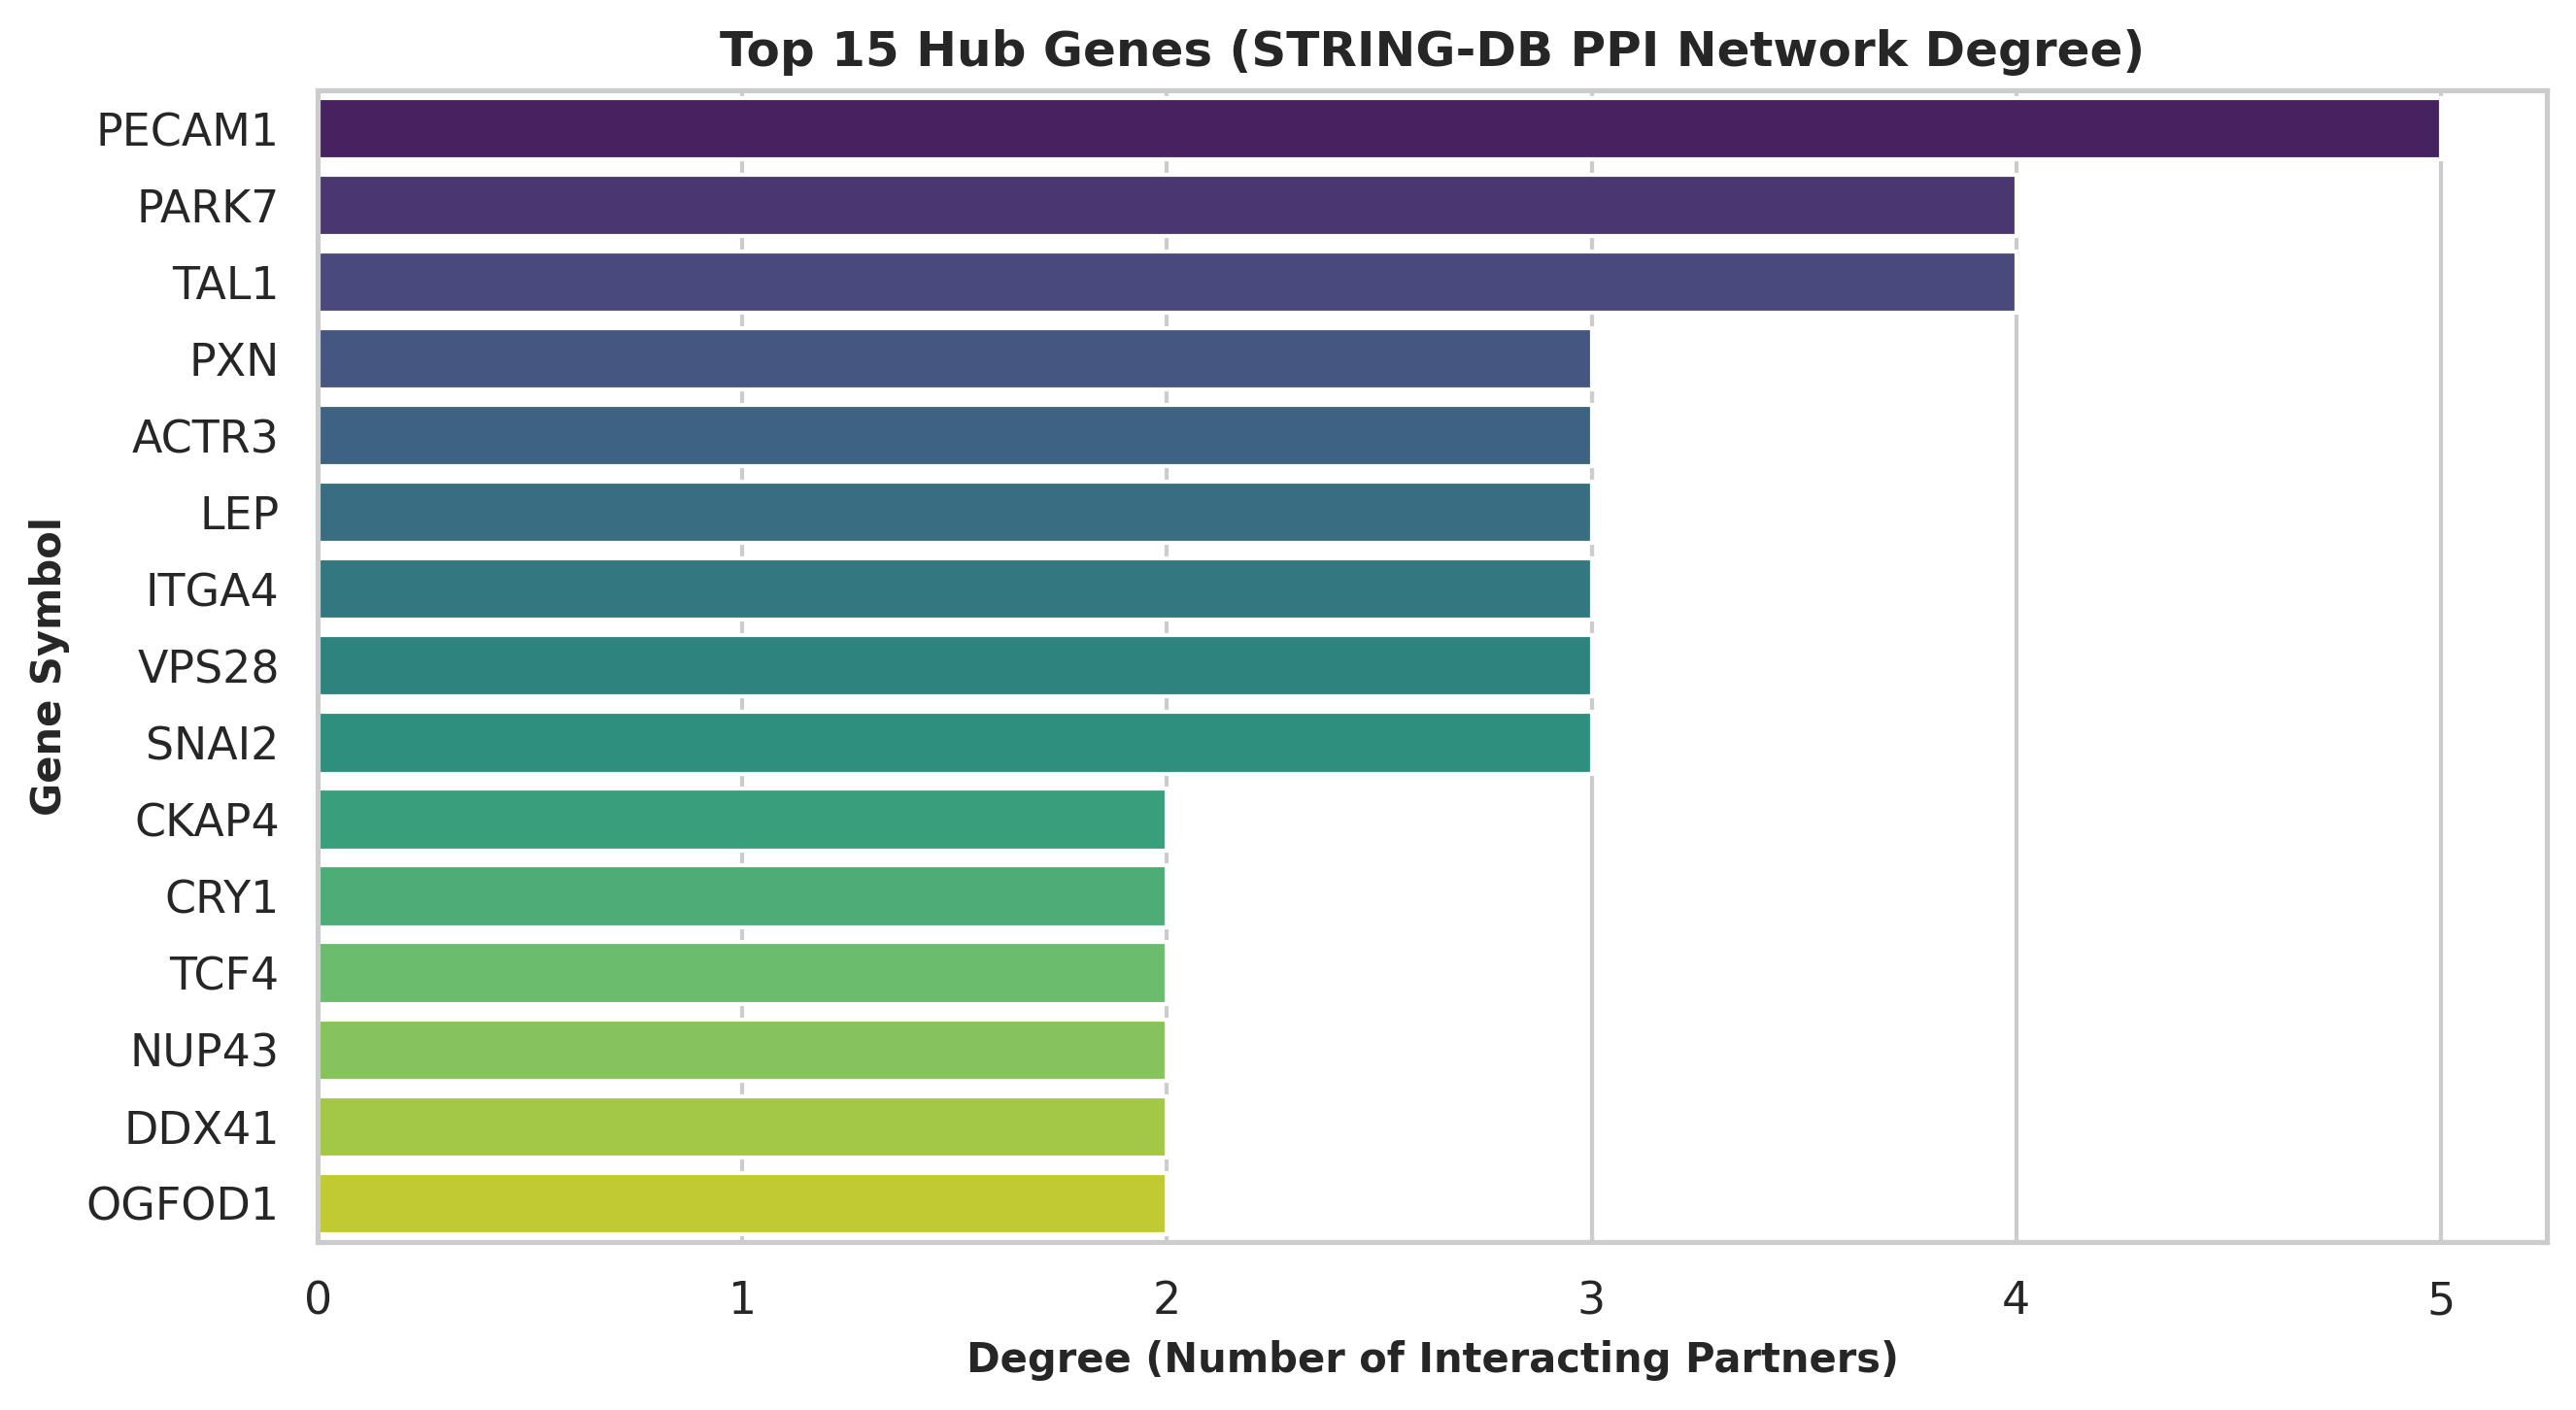


[Step 3/3] Querying Open Targets API for Lung Carcinoma Associations...
⚠️ Open Targets returned no data or invalid response structure.

=== Click Links Below to Download Analysis Outputs ===

--- CSV Reports ---


/kaggle/working/all_pathway_enrichment_results.csv

/kaggle/working/top_hub_genes_ppi.csv

/kaggle/working/validated_lung_cancer_associated_genes.csv


--- Figures ---


/kaggle/working/kegg_pathways_enrichment.png

/kaggle/working/top_hub_genes_ppi.png

In [6]:
# Install gseapy if running in Kaggle
!pip install -q gseapy

import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import gseapy as gp
from IPython.display import FileLink, display

# -------------------------------------------------------------------
# 1. Load Top 100 Genes
# -------------------------------------------------------------------
csv_path = 'top_100_genes_direct_lime.csv'

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"⚠️ Could not find '{csv_path}'. Make sure your previous evaluation script ran successfully!")

df_genes = pd.read_csv(csv_path)

# Extract gene symbols
gene_list = df_genes['Gene'].dropna().astype(str).tolist()
print(f"✅ Loaded {len(gene_list)} genes from '{csv_path}'.")

# -------------------------------------------------------------------
# 2. KEGG, GO, & Reactome Pathway Enrichment (gseapy)
# -------------------------------------------------------------------
print("\n[Step 1/3] Running Pathway & GO Enrichment Analysis...")

gene_sets = ['KEGG_2021_Human', 'GO_Biological_Process_2023', 'Reactome_2022']

try:
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=gene_sets,
        organism='Human',
        outdir='enrichment_outputs',
        cutoff=0.05
    )

    enrich_results = enr.results
    enrich_results.to_csv('all_pathway_enrichment_results.csv', index=False)

    # Filter Top 10 KEGG Pathways
    kegg_df = enrich_results[enrich_results['Gene_set'] == 'KEGG_2021_Human'].sort_values(by='Adjusted P-value').head(10)

    print("\n--- Top Enriched KEGG Pathways ---")
    if not kegg_df.empty:
        print(kegg_df[['Term', 'Overlap', 'P-value', 'Adjusted P-value']].head(5).to_string(index=False))

        # Plot KEGG Enrichment Bar Plot
        plt.figure(figsize=(9, 5), dpi=300)
        sns.barplot(
            data=kegg_df,
            x='Adjusted P-value',
            y='Term',
            palette='Blues_r'
        )
        plt.title('Top Enriched KEGG Pathways (LIME Top 100 Genes)', fontsize=12, fontweight='bold')
        plt.xlabel('Adjusted P-Value (FDR)', fontsize=10, fontweight='bold')
        plt.ylabel('Pathway Term', fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.savefig('kegg_pathways_enrichment.png', dpi=300)
        plt.show()
    else:
        print("No KEGG pathways met the cutoff threshold (Adjusted P-value < 0.05).")

except Exception as e:
    print(f"⚠️ Pathway Enrichment Failed: {e}")

# -------------------------------------------------------------------
# 3. Protein-Protein Interaction (PPI) Network & Hub Genes (STRING API)
# -------------------------------------------------------------------
print("\n[Step 2/3] Querying STRING-DB API for PPI Network & Hub Genes...")

string_api_url = "https://version-11-5.string-db.org/api/json/network"
params = {
    "identifiers": "\r".join(gene_list),
    "species": 9606,            # Homo Sapiens NCBI Taxonomy ID
    "required_score": 400,       # Medium confidence threshold (0.40)
    "caller_identity": "lung_cancer_gene_analysis"
}

try:
    response = requests.post(string_api_url, data=params, timeout=30)

    if response.status_code == 200:
        interactions = response.json()
        
        # Build Network Graph
        G = nx.Graph()
        for edge in interactions:
            p1 = edge['preferredName_A']
            p2 = edge['preferredName_B']
            score = float(edge['score'])
            G.add_edge(p1, p2, weight=score)
            
        print(f"✅ PPI Network Built: {G.number_of_nodes()} Nodes | {G.number_of_edges()} Edges")
        
        # Calculate Hub Gene Centrality Scores
        degree_dict = dict(G.degree())
        betweenness_dict = nx.betweenness_centrality(G)
        
        hub_df = pd.DataFrame({
            'Gene': list(degree_dict.keys()),
            'Interaction_Degree': list(degree_dict.values()),
            'Betweenness_Centrality': [betweenness_dict[g] for g in degree_dict.keys()]
        }).sort_values(by='Interaction_Degree', ascending=False).reset_index(drop=True)
        
        hub_df.to_csv('top_hub_genes_ppi.csv', index=False)
        
        print("\n--- Top 10 Hub Genes Identified ---")
        print(hub_df.head(10).to_string(index=False))
        
        # Plot Top 15 Hub Genes Barplot
        plt.figure(figsize=(9, 5), dpi=300)
        sns.barplot(
            data=hub_df.head(15),
            x='Interaction_Degree',
            y='Gene',
            palette='viridis'
        )
        plt.title('Top 15 Hub Genes (STRING-DB PPI Network Degree)', fontsize=12, fontweight='bold')
        plt.xlabel('Degree (Number of Interacting Partners)', fontsize=10, fontweight='bold')
        plt.ylabel('Gene Symbol', fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.savefig('top_hub_genes_ppi.png', dpi=300)
        plt.show()
    else:
        print("⚠️ STRING API request failed. Status code:", response.status_code)
except Exception as e:
    print(f"⚠️ STRING API Connection Failed: {e}")

# -------------------------------------------------------------------
# 4. Disease Association Query (Open Targets API)
# -------------------------------------------------------------------
print("\n[Step 3/3] Querying Open Targets API for Lung Carcinoma Associations...")

ot_graphql_url = "https://api.platform.opentargets.org/api/v4/graphql"

# Standard query retrieving targets associated with Lung Carcinoma (EFO_0001071)
query = """
query AssociatedTargets($diseaseId: String!) {
  disease(efoId: $diseaseId) {
    name
    associatedTargets(page: {index: 0, size: 1000}) {
      rows {
        target {
          approvedSymbol
        }
        score
      }
    }
  }
}
"""

variables = {"diseaseId": "EFO_0001071"}  # EFO code for Lung Carcinoma

try:
    ot_response = requests.post(ot_graphql_url, json={'query': query, 'variables': variables}, timeout=30)

    if ot_response.status_code == 200:
        res_json = ot_response.json()
        if 'data' in res_json and res_json['data']['disease'] is not None:
            ot_data = res_json['data']['disease']['associatedTargets']['rows']
            
            ot_df = pd.DataFrame([
                {'Gene': row['target']['approvedSymbol'], 'Lung_Cancer_Association_Score': row['score']}
                for row in ot_data if row.get('target') and row['target'].get('approvedSymbol')
            ])
            
            # Merge with your top 100 gene list
            validated_disease_genes = df_genes.merge(ot_df, on='Gene', how='inner').sort_values(
                by='Lung_Cancer_Association_Score', ascending=False
            ).reset_index(drop=True)
            
            validated_disease_genes.to_csv('validated_lung_cancer_associated_genes.csv', index=False)
            
            print(f"✅ Found {len(validated_disease_genes)} / {len(gene_list)} genes with documented lung cancer evidence in Open Targets!")
            print("\n--- Top Confirmed Lung Cancer Genes ---")
            print(validated_disease_genes[['Gene', 'Mean_Importance_Score', 'Lung_Cancer_Association_Score']].head(10).to_string(index=False))
        else:
            print("⚠️ Open Targets returned no data or invalid response structure.")
    else:
        print("⚠️ Open Targets API HTTP request failed:", ot_response.status_code)
except Exception as e:
    print(f"⚠️ Open Targets API Query Failed: {e}")

# -------------------------------------------------------------------
# 5. File Download Links
# -------------------------------------------------------------------
print("\n=== Click Links Below to Download Analysis Outputs ===")

print("\n--- CSV Reports ---")
display(FileLink('all_pathway_enrichment_results.csv'))
display(FileLink('top_hub_genes_ppi.csv'))
display(FileLink('validated_lung_cancer_associated_genes.csv'))

print("\n--- Figures ---")
display(FileLink('kegg_pathways_enrichment.png'))
display(FileLink('top_hub_genes_ppi.png'))